<a href="https://colab.research.google.com/github/luu-quang/Data_Mining_and_Machine_Learning_USTH/blob/Khanh/RecSys_binary_FE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Feature engineer document:
Chia df ban đầu thành các tập cột: customer_info_cols: thông tin khách hàng và target: 24 cột sản phẩm
Chúng ta có 16 tháng dữ liệu, từ 1/2015 - 4/2016 (tôi chỉ load đc 12,5tr hàng nên chắc ko đủ? full là hơn 13tr),
từ bây giờ tôi sẽ gọi tháng theo số thứ tự của nó: 1 -> 16

Dữ liệu mua mới: với mỗi tháng từ tháng 7 đến 15, ta sẽ lấy dữ liệu 6 tháng trước để làm dữ liệu train, kết quả tháng đó làm target
Biến đổi: không dùng nguyên dữ liệu theo tháng(người đó có sở hữu sản phẩm đấy hay không), mà dùng dữ liệu mua mới:(last_month==0)&(this_month==1):
tháng này có mua mới sản phẩm đấy hay không. Dùng thông tin này vì đoán xem tháng này khách hàng sở hữu gì kém ý nghĩa hơn khách hàng sẽ mua mới gì.
-> 6 cột mua mới của 6 tháng trước tháng này
Dữ liệu thời gian: dùng month_sin và month_cos để mã hoá vòng thời gian theo chu kỳ năm (tháng 14 cùng giá trị mã hoá với tháng 2)
Dữ liệu xu hướng: mới mỗi 2 cột mua mới, tính tỉ lệ mua mới cho mỗi cột -> tỉ lệ mua mới của 2 tháng đó -> lấy tháng này trừ tháng trước
-> xu hướng mua mới sản phẩm.(6 cột -> 5 cặp) -> 5 cột xu hướng mua mới

Encoding: cột nào chỉ có 2 giá trị -> 0/1, cột có dưới 10 category->one-hot, cột có nhiều category->target
Sau khi thực hiện các bước trên, chúng ta có dataframe sau: 24*6(mua mới)+24*5(xu hướng mua mới)+17(customer_info_cols)+2(month_sin/cos)+24(target)=207 cột
customer_code   employee_index  customer_country    sex age new_index   seniority_months    primary_customer    month_start_type    relation_type   residence_index foreigner_index join_channel    province_code   activity_index  gross_househole_income  segment month_sin   month_cos   product_1_last_6    product_2_last_6    product_3_last_6    product_4_last_6    product_5_last_6    product_6_last_6    product_7_last_6    product_8_last_6    product_9_last_6    product_10_last_6   product_11_last_6   product_12_last_6   product_13_last_6   product_14_last_6   product_15_last_6   product_16_last_6   product_17_last_6   product_18_last_6   product_19_last_6   product_20_last_6   product_21_last_6   product_22_last_6   product_23_last_6   product_24_last_6   product_1_last_5    product_2_last_5    product_3_last_5    product_4_last_5    product_5_last_5    product_6_last_5    product_7_last_5    product_8_last_5    product_9_last_5    product_10_last_5   product_11_last_5   product_12_last_5   product_13_last_5   product_14_last_5   product_15_last_5   product_16_last_5   product_17_last_5   product_18_last_5   product_19_last_5   product_20_last_5   product_21_last_5   product_22_last_5   product_23_last_5   product_24_last_5   product_1_last_4    product_2_last_4    product_3_last_4    product_4_last_4    product_5_last_4    product_6_last_4    product_7_last_4    product_8_last_4    product_9_last_4    product_10_last_4   product_11_last_4   product_12_last_4   product_13_last_4   product_14_last_4   product_15_last_4   product_16_last_4   product_17_last_4   product_18_last_4   product_19_last_4   product_20_last_4   product_21_last_4   product_22_last_4   product_23_last_4   product_24_last_4   product_1_last_3    product_2_last_3    product_3_last_3    product_4_last_3    product_5_last_3    product_6_last_3    product_7_last_3    product_8_last_3    product_9_last_3    product_10_last_3   product_11_last_3   product_12_last_3   product_13_last_3   product_14_last_3   product_15_last_3   product_16_last_3   product_17_last_3   product_18_last_3   product_19_last_3   product_20_last_3   product_21_last_3   product_22_last_3   product_23_last_3   product_24_last_3   product_1_last_2    product_2_last_2    product_3_last_2    product_4_last_2    product_5_last_2    product_6_last_2    product_7_last_2    product_8_last_2    product_9_last_2    product_10_last_2   product_11_last_2   product_12_last_2   product_13_last_2   product_14_last_2   product_15_last_2   product_16_last_2   product_17_last_2   product_18_last_2   product_19_last_2   product_20_last_2   product_21_last_2   product_22_last_2   product_23_last_2   product_24_last_2   product_1_last_1    product_2_last_1    product_3_last_1    product_4_last_1    product_5_last_1    product_6_last_1    product_7_last_1    product_8_last_1    product_9_last_1    product_10_last_1   product_11_last_1   product_12_last_1   product_13_last_1   product_14_last_1   product_15_last_1   product_16_last_1   product_17_last_1   product_18_last_1   product_19_last_1   product_20_last_1   product_21_last_1   product_22_last_1   product_23_last_1   product_24_last_1   product_1_last_0    product_2_last_0    product_3_last_0    product_4_last_0    product_5_last_0    product_6_last_0    product_7_last_0    product_8_last_0    product_9_last_0    product_10_last_0   product_11_last_0   product_12_last_0   product_13_last_0   product_14_last_0   product_15_last_0   product_16_last_0   product_17_last_0   product_18_last_0   product_19_last_0   product_20_last_0   product_21_last_0   product_22_last_0   product_23_last_0   product_24_last_0   product_1_diff_last_5   product_2_diff_last_5   product_3_diff_last_5   product_4_diff_last_5   product_5_diff_last_5   product_6_diff_last_5   product_7_diff_last_5   product_8_diff_last_5   product_9_diff_last_5   product_10_diff_last_5  product_11_diff_last_5  product_12_diff_last_5  product_13_diff_last_5  product_14_diff_last_5  product_15_diff_last_5  product_16_diff_last_5  product_17_diff_last_5  product_18_diff_last_5  product_19_diff_last_5  product_20_diff_last_5  product_21_diff_last_5  product_22_diff_last_5  product_23_diff_last_5  product_24_diff_last_5  product_1_diff_last_4   product_2_diff_last_4   product_3_diff_last_4   product_4_diff_last_4   product_5_diff_last_4   product_6_diff_last_4   product_7_diff_last_4   product_8_diff_last_4   product_9_diff_last_4   product_10_diff_last_4  product_11_diff_last_4  product_12_diff_last_4  product_13_diff_last_4  product_14_diff_last_4  product_15_diff_last_4  product_16_diff_last_4  product_17_diff_last_4  product_18_diff_last_4  product_19_diff_last_4  product_20_diff_last_4  product_21_diff_last_4  product_22_diff_last_4  product_23_diff_last_4  product_24_diff_last_4  product_1_diff_last_3   product_2_diff_last_3   product_3_diff_last_3   product_4_diff_last_3   product_5_diff_last_3   product_6_diff_last_3   product_7_diff_last_3   product_8_diff_last_3   product_9_diff_last_3   product_10_diff_last_3  product_11_diff_last_3  product_12_diff_last_3  product_13_diff_last_3  product_14_diff_last_3  product_15_diff_last_3  product_16_diff_last_3  product_17_diff_last_3  product_18_diff_last_3  product_19_diff_last_3  product_20_diff_last_3  product_21_diff_last_3  product_22_diff_last_3  product_23_diff_last_3  product_24_diff_last_3  product_1_diff_last_2   product_2_diff_last_2   product_3_diff_last_2   product_4_diff_last_2   product_5_diff_last_2   product_6_diff_last_2   product_7_diff_last_2   product_8_diff_last_2   product_9_diff_last_2   product_10_diff_last_2  product_11_diff_last_2  product_12_diff_last_2  product_13_diff_last_2  product_14_diff_last_2  product_15_diff_last_2  product_16_diff_last_2  product_17_diff_last_2  product_18_diff_last_2  product_19_diff_last_2  product_20_diff_last_2  product_21_diff_last_2  product_22_diff_last_2  product_23_diff_last_2  product_24_diff_last_2  product_1_diff_last_1   product_2_diff_last_1   product_3_diff_last_1   product_4_diff_last_1   product_5_diff_last_1   product_6_diff_last_1   product_7_diff_last_1   product_8_diff_last_1   product_9_diff_last_1   product_10_diff_last_1  product_11_diff_last_1  product_12_diff_last_1  product_13_diff_last_1  product_14_diff_last_1  product_15_diff_last_1  product_16_diff_last_1  product_17_diff_last_1  product_18_diff_last_1  product_19_diff_last_1  product_20_diff_last_1  product_21_diff_last_1  product_22_diff_last_1  product_23_diff_last_1  product_24_diff_last_1
product_i_last_n: cột mua mới của sản phẩm i vào n tháng trước tháng hiện tại
product_i_diff_last_n: cột xu hướng mua mới của sản phẩm i vào n tháng trước tháng hiện tại
Theo cách này ta tạo được 9 tháng dữ liệu train(7-15)

Tiếp theo, ý tưởng của tôi là với mỗi hàng đang có dữ liệu của cả 24 sản phẩm, mình sẽ biến thành 24 hàng, mỗi hàng có thông tin 1 sản phẩm thôi
17(customer_info_cols)+2(month_sin/cos)+6(mua mới)+5(xu hướng mua mới)+product+new_buy
product: mã số của sản phẩm(1-24), sẽ one-hot encode trước khi train
new_buy: 0/1, có mua mới sản phẩm đấy không

Nhưng vì hầu hết khách hàng sẽ không mua mới, nên có quá nhiều negative(không mua mới) so với positive(mua mới).
Ta sẽ làm negative downsampling theo cách sau:
với mỗi sản phẩm, ta tính tổng số positive(1) của nó, rồi quyết định xem sẽ giữ bao nhiêu hàng negative(0) của cùng sản phẩm đó theo cách sau:
def ratio_to_positive(n_1): (tỉ số negative(0) để giữ so với positive(1))
  if n_1 < 20:
    return 10
  if 100 > n_1 >= 20:
    return 5
  if 1000 > n_1 >= 100:
    return 3
  else:
    return 2
Với các sản phẩm hiếm người mua, ta lấy nhiều negative(0) hơn để model hiểu rõ hơn về nó và phản ánh đúng là nhiều người không mua mới.
Kết quả:
customer_code   product new_buy employee_index  customer_country    sex age new_index   seniority_months    primary_customer    month_start_type    relation_type   residence_index foreigner_index join_channel    province_code   activity_index  gross_househole_income  segment month_sin   month_cos   product_last_6  product_last_5  product_last_4  product_last_3  product_last_2  product_last_1  product_diff_last_5 product_diff_last_4 product_diff_last_3 product_diff_last_2 product_diff_last_1
Làm tương tự với tháng thứ 16 ta có tập validation
Chạy model với binary classification cho ra xác suất của người đấy với mỗi sản phẩm, chọn 3 sản phẩm có xác suất cao nhất để kiểm tra với Mean Average Precision
Lưu ý, vì RAM colab free là 12Gb nên cần downcast dtype xuống (0/1->int8, ko cần float64 thì dùng float32, int64 là siêu lãng phí)
====The End====

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install display
import missingno as msno
import gc #để xoá object khỏi ram khi không cần nữa

from google.colab import drive
#drive ngáo lắm phải forece_remount
drive.mount("/content/drive", force_remount=True)
import shutil
import os
import pyarrow.parquet as pq
import pyarrow as pa

pd.set_option('display.max_columns', None)
if hasattr(pd, 'options'):
    pd.options.mode.copy_on_write = True  #chỉ tạo copy của dataframe khi có hành động write->kiểm soát số lượng copy

  Preparing metadata (setup.py) ... done
  Created wheel for display: filename=display-1.0.0-py3-none-any.whl size=1380 sha256=11c5effd50ba2e16675bf402fd37aea1f071f2f97d5896b40449d6fdc1f34f91
  Stored in directory: /root/.cache/pip/wheels/aa/37/3e/1ab7472ef100105e66476aec658aa95980b913260d4b48fcdc
Successfully built display
Mounted at /content/drive


In [ ]:
#parquet giảm xuống còn hơn 4Gb :))) load đc full file (đổi hết dtype của các cột product làm np.int8)
parquet_dataset = "/content/drive/My Drive/bank_data/train_parquet/" #đây là file để chạy ban đầu
train_parquet = "/content/drive/My Drive/bank_data/train.parquet" #đây là file sau khi đổi dtype
df = pd.read_parquet(train_parquet)
df = df.sort_values('date')
print(df.head())

             date  customer_code employee_index customer_country  sex  age  \
0      2015-01-28        1271057              N               ES    0   22   
412289 2015-01-28        1162939              N               ES    1   50   
412290 2015-01-28        1162936              N               ES    0   23   
412291 2015-01-28        1162935              N               ES    0   22   
412292 2015-01-28        1162934              N               ES    0   23   

        new_index  seniority_months  primary_customer month_start_type  \
0               0                12                 1              1.0   
412289          0                23                 1              1.0   
412290          0                23                 1              1.0   
412291          0                23                 1              1.0   
412292          0                23                 1              1.0   

       relation_type  residence_index  foreigner_index join_channel  \
0              

In [ ]:
#temporal features
df['month_int'] = ((df['date'].dt.year - 2015)*12 + df['date'].dt.month).astype(np.int8)
df['month_sin'] = np.sin(2*np.pi*(df['month_int']%12)/12).astype(np.float32)
df['month_cos'] = np.cos(2*np.pi*(df['month_int']%12)/12).astype(np.float32)
df['province_code'] = df['province_code'].astype(np.int8)

In [ ]:
month_int = list(range(1,17))

In [2]:
target = ["product_1","product_2",
              "product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]

In [3]:
customer_info_cols = ['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type', 'residence_index', 'foreigner_index', 'join_channel',
       'province_code', 'activity_index', 'gross_househole_income', 'segment']

In [ ]:
#saving RAM by changing dtype + encoding
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
df['month_start_type'] = pd.to_numeric(df['month_start_type'], errors='coerce')
df['month_start_type'] = df['month_start_type'].astype('string').fillna('P')
df['month_start_type'] = df['month_start_type'].astype('string')
for col in categorical_cols+high_cardinal_cols:
  df[col] = df[col].astype('category')
for col in int8_cols:
  df[col] = df[col].astype(np.int8)
for col in int16_cols:
  df[col] = df[col].astype(np.int16)
for col in to_binary_cols:
  print(df[col].isnull().sum())
df['sex'] = df['sex'].replace('nan', np.nan).map({'H':0, 'V':1})
df['sex'] = df['sex'].fillna(df['sex'].mode()[0]).astype(np.int8)
df['primary_customer'] = df['primary_customer'].map({99:0, 1:1}).fillna(df['primary_customer'].mode()[0]).astype(np.int8)
df['residence_index'] = df['residence_index'].map({'N':0, 'S':1}).fillna(df['residence_index'].mode()[0]).astype(np.int8)
df['foreigner_index'] = df['foreigner_index'].map({'N':0, 'S':1}).fillna(df['foreigner_index'].mode()[0]).astype(np.int8)
df['customer_code'] = df['customer_code'].astype(np.int32)

0
0
0
0


In [ ]:
#cái này có 'nan' chứ ko phải np.nan :))
#không nên để tất cả lệnh vào 1 dòng:
#df['sex'] = df['sex'].replace('nan', np.nan).map({'H':0, 'V':1}).fillna(df['sex'].mode()[0]).astype(np.int8)
#vì như thế rất có thể df['sex'].mode()[0] đc tính xong trước khi df['sex'].replace('nan', np.nan) do parrallel processing chắc vậy, và bùm lỗi
#tách thành 2 dòng
#df['sex'] = df['sex'].replace('nan', np.nan).map({'H':0, 'V':1})
#df['sex'] = df['sex'].fillna(df['sex'].mode()[0]).astype(np.int8)

print(df['sex'].unique())
print(df['sex'].value_counts())

[0 1]
sex
1    6853655
0    5704287
Name: count, dtype: int64


In [ ]:
#lưu vào file khác để lần sau không phải chạy lại
train_parquet = "/content/drive/My Drive/bank_data/train.parquet"
df.to_parquet(train_parquet, index=False)

In [ ]:
#chia dataframe theo tháng(7-15), với mỗi tháng tạo cột mua mới và xu hướng mua mới
#CHÚ Ý: cách làm này là căn cứ vào không có customer_id bị lặp trong 1 tháng bất kỳ
#tháng 1: bản thân nó là dữ liệu mua mới luôn vì không có dữ liệu tháng trước đó
#với tạo cột mua mới: với 6 tháng train: dùng outer merge để nếu có khách hàng mới/rời khỏi thì coi như tháng trước/sau họ không mua mới(=0)
#nhưng ở tháng thứ 7(target), mình dùng left merge(6th_month, 7th_month) vì mình cần dự đoán mua mới ở tháng 7 dựa theo dữ liệu 6 tháng trc
#với customer_info_cols thì dùng combine_first, tương tự outer merge nhưng nhỡ có người đổi dữ liệu thì dùng dữ liệu mới nhất
import pyarrow.parquet as pq
import pyarrow as pa
binary_train_dataset = '/content/drive/My Drive/bank_data/binary_train_dataset/'
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
import shutil
import os
if os.path.exists(merged_train_dataset):
  shutil.rmtree(merged_train_dataset)
assert not os.path.exists(merged_train_dataset), "Dataset already exists!"
os.mkdir(merged_train_dataset)
merge_cols = target.copy()
merge_cols = ['customer_code'] + merge_cols
#10 = (16-7)/1+1
for i in range(1, 10):
  if i==1:
    df_7_months = df.loc[df['month_int']==i, ['customer_code']+target].copy()
    df_7_months.rename(columns={product: product+f'_last_6' for product in target}, inplace=True)
    new_buy_cols = []
    new_buy_p_dict = {}
    new_buy_diff_dict = {}
    for product in target:
      new_buy_cols.append(product+'_last_6}')
      new_buy_p_dict[product+'_p_last_6'] = df_7_months[product+f'_last_6'].mean()
    for month in range(i+1,i+7):
      df_this_month = df.loc[df['month_int']==month, merge_cols]
      df_last_month = df.loc[df['month_int']==month-1, merge_cols]
      if month == i+6:
        df_merged = df_last_month.merge(df_this_month, on='customer_code', how='left', suffixes=('_this_month', '_last_month'))
      else:
        df_merged = df_this_month.merge(df_last_month, on='customer_code', how='outer', suffixes=('_this_month', '_last_month'))
      del df_this_month
      del df_last_month
      gc.collect()
      this_month_cols = [product+'_this_month' for product in target]
      last_month_cols = [product+'_last_month' for product in target]
      fill_dict = {col:0 for col in this_month_cols+last_month_cols}
      df_merged = df_merged.fillna(fill_dict)

      for product in target:
        df_merged[product+f'_last_{i+6-month}'] = ((df_merged[product+'_last_month']==0)&(df_merged[product+'_this_month']==1)).astype(np.int8)
        new_buy_cols.append(product+f'_last_{i+6-month}')
        new_buy_p_dict[product+f'_p_last_{i+6-month}'] = df_merged[product+f'_last_{i+6-month}'].mean()
        if (product+f'_p_last_{i+6-month+1}' in new_buy_p_dict.keys()) and (i+6-month != 0):
          new_buy_diff_dict[product+f'_diff_last_{i+6-month}'] = new_buy_p_dict[product+f'_p_last_{i+6-month}'] - new_buy_p_dict[product+f'_p_last_{i+6-month+1}']

      df_merged = df_merged.drop(this_month_cols+last_month_cols, axis=1)
      gc.collect()
      df_7_months = df_7_months.merge(df_merged, on='customer_code', how='outer')
      del df_merged
      gc.collect()
  else:
    df_7_months = df.loc[df['month_int']==i, ['customer_code']].copy()
    new_buy_cols = []
    new_buy_p_dict = {}
    new_buy_diff_dict = {}
    for month in range(i,i+7):
      df_this_month = df.loc[df['month_int']==month, merge_cols]
      df_last_month = df.loc[df['month_int']==month-1, merge_cols]
      if month == i+6:
        df_merged = df_last_month.merge(df_this_month, on='customer_code', how='left', suffixes=('_this_month', '_last_month'))
      else:
        df_merged = df_this_month.merge(df_last_month, on='customer_code', how='outer', suffixes=('_this_month', '_last_month'))
      del df_this_month
      del df_last_month
      gc.collect()
      this_month_cols = [product+'_this_month' for product in target]
      last_month_cols = [product+'_last_month' for product in target]
      fill_dict = {col:0 for col in this_month_cols+last_month_cols}
      df_merged = df_merged.fillna(fill_dict)
      for product in target:
        df_merged[product+f'_last_{i+6-month}'] = ((df_merged[product+'_last_month']==0)&(df_merged[product+'_this_month']==1)).astype(np.int8)
        new_buy_cols.append(product+f'_last_{i+6-month}')
        new_buy_p_dict[product+f'_p_last_{i+6-month}'] = df_merged[product+f'_last_{i+6-month}'].mean()
        if (product+f'_p_last_{i+6-month+1}' in new_buy_p_dict.keys()) and (i+6-month != 0):
          new_buy_diff_dict[product+f'_diff_last_{i+6-month}'] = new_buy_p_dict[product+f'_p_last_{i+6-month}'] - new_buy_p_dict[product+f'_p_last_{i+6-month+1}']
      df_merged = df_merged.drop(this_month_cols+last_month_cols, axis=1)
      gc.collect()
      df_7_months = df_7_months.merge(df_merged, on='customer_code', how='outer')
      del df_merged
      gc.collect()

  print(df_7_months.columns[df_7_months.columns.str.contains('_last_')])
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  fill_dict = {col:0 for col in df_7_months if '_last_' in col}
  df_7_months = df_7_months.fillna(fill_dict)
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  new_cols_df = pd.DataFrame({key: value.astype(np.float32) for key, value in new_buy_diff_dict.items()}, index=df_7_months.index)
  df_7_months = pd.concat([df_7_months, new_cols_df], axis=1)
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  del new_cols_df
  gc.collect()
  display(df_7_months.shape)
  #customer_info_cols for training, same number of row as df_6_months
  df_customer_info = df.loc[df['month_int']==i, customer_info_cols+['month_sin', 'month_cos']]
  for month in range(i+1,i+6):
    df_right = df.loc[df['month_int']==month, customer_info_cols+['month_sin', 'month_cos']]
    df_customer_info = df_right.set_index('customer_code').combine_first(df_customer_info.set_index('customer_code')).reset_index()
    del df_right
    gc.collect()
  display(df_customer_info.shape)

  df_customer_info = df_customer_info.merge(df_7_months, on='customer_code')
  display(df_customer_info.head())
  del df_7_months
  gc.collect()
  table = pa.Table.from_pandas(df_customer_info)
  del df_customer_info
  gc.collect()
  filepath = f"{merged_train_dataset}chunk_{i}.parquet"
  pq.write_table(table, filepath)
  del table
  gc.collect()

Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dtype='object', length=168)
Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dt

(636674, 289)

(636674, 19)

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_1_last_6,product_2_last_6,product_3_last_6,product_4_last_6,product_5_last_6,product_6_last_6,product_7_last_6,product_8_last_6,product_9_last_6,product_10_last_6,product_11_last_6,product_12_last_6,product_13_last_6,product_14_last_6,product_15_last_6,product_16_last_6,product_17_last_6,product_18_last_6,product_19_last_6,product_20_last_6,product_21_last_6,product_22_last_6,product_23_last_6,product_24_last_6,product_1_last_5,product_2_last_5,product_3_last_5,product_4_last_5,product_5_last_5,product_6_last_5,product_7_last_5,product_8_last_5,product_9_last_5,product_10_last_5,product_11_last_5,product_12_last_5,product_13_last_5,product_14_last_5,product_15_last_5,product_16_last_5,product_17_last_5,product_18_last_5,product_19_last_5,product_20_last_5,product_21_last_5,product_22_last_5,product_23_last_5,product_24_last_5,product_1_last_4,product_2_last_4,product_3_last_4,product_4_last_4,product_5_last_4,product_6_last_4,product_7_last_4,product_8_last_4,product_9_last_4,product_10_last_4,product_11_last_4,product_12_last_4,product_13_last_4,product_14_last_4,product_15_last_4,product_16_last_4,product_17_last_4,product_18_last_4,product_19_last_4,product_20_last_4,product_21_last_4,product_22_last_4,product_23_last_4,product_24_last_4,product_1_last_3,product_2_last_3,product_3_last_3,product_4_last_3,product_5_last_3,product_6_last_3,product_7_last_3,product_8_last_3,product_9_last_3,product_10_last_3,product_11_last_3,product_12_last_3,product_13_last_3,product_14_last_3,product_15_last_3,product_16_last_3,product_17_last_3,product_18_last_3,product_19_last_3,product_20_last_3,product_21_last_3,product_22_last_3,product_23_last_3,product_24_last_3,product_1_last_2,product_2_last_2,product_3_last_2,product_4_last_2,product_5_last_2,product_6_last_2,product_7_last_2,product_8_last_2,product_9_last_2,product_10_last_2,product_11_last_2,product_12_last_2,product_13_last_2,product_14_last_2,product_15_last_2,product_16_last_2,product_17_last_2,product_18_last_2,product_19_last_2,product_20_last_2,product_21_last_2,product_22_last_2,product_23_last_2,product_24_last_2,product_1_last_1,product_2_last_1,product_3_last_1,product_4_last_1,product_5_last_1,product_6_last_1,product_7_last_1,product_8_last_1,product_9_last_1,product_10_last_1,product_11_last_1,product_12_last_1,product_13_last_1,product_14_last_1,product_15_last_1,product_16_last_1,product_17_last_1,product_18_last_1,product_19_last_1,product_20_last_1,product_21_last_1,product_22_last_1,product_23_last_1,product_24_last_1,product_1_last_0,product_2_last_0,product_3_last_0,product_4_last_0,product_5_last_0,product_6_last_0,product_7_last_0,product_8_last_0,product_9_last_0,product_10_last_0,product_11_last_0,product_12_last_0,product_13_last_0,product_14_last_0,product_15_last_0,product_16_last_0,product_17_last_0,product_18_last_0,product_19_last_0,product_20_last_0,product_21_last_0,product_22_last_0,product_23_last_0,product_24_last_0,product_1_diff_last_5,product_2_diff_last_5,product_3_diff_last_5,product_4_diff_last_5,product_5_diff_last_5,product_6_diff_last_5,product_7_diff_last_5,product_8_diff_last_5,product_9_diff_last_5,product_10_diff_last_5,product_11_diff_last_5,product_12_diff_last_5,product_13_diff_last_5,product_14_diff_last_5,product_15_diff_last_5,product_16_diff_last_5,product_17_diff_last_5,product_18_diff_last_5,product_19_diff_last_5,product_20_diff_last_5,product_21_diff_last_5,product_22_diff_last_5,product_23_diff_last_5,product_24_diff_last_5,product_1_diff_last_4,product_2_diff_last_4,product_3_diff_last_4,product_4_diff_last_4,product_5_diff_last_4,product_6_diff_last_4,product_7_diff_last_4,product_8_diff_last_4,product_9_diff_last_4,product_10_diff_last_4,product_11_diff_last

Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dtype='object', length=168)
Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_2', 'product_16_last_2', 'product_17_last_2',
       'product_18_last_2', 'product_19_last_2', 'product_20_last_2',
       'product_21_last_2', 'product_22_last_2', 'product_23_last_2',
       'product_24_last_2'],
      dt

...

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_1_last_6,product_2_last_6,product_3_last_6,product_4_last_6,product_5_last_6,product_6_last_6,product_7_last_6,product_8_last_6,product_9_last_6,product_10_last_6,product_11_last_6,product_12_last_6,product_13_last_6,product_14_last_6,product_15_last_6,product_16_last_6,product_17_last_6,product_18_last_6,product_19_last_6,product_20_last_6,product_21_last_6,product_22_last_6,product_23_last_6,product_24_last_6,product_1_last_5,product_2_last_5,product_3_last_5,product_4_last_5,product_5_last_5,product_6_last_5,product_7_last_5,product_8_last_5,product_9_last_5,product_10_last_5,product_11_last_5,product_12_last_5,product_13_last_5,product_14_last_5,product_15_last_5,product_16_last_5,product_17_last_5,product_18_last_5,product_19_last_5,product_20_last_5,product_21_last_5,product_22_last_5,product_23_last_5,product_24_last_5,product_1_last_4,product_2_last_4,product_3_last_4,product_4_last_4,product_5_last_4,product_6_last_4,product_7_last_4,product_8_last_4,product_9_last_4,product_10_last_4,product_11_last_4,product_12_last_4,product_13_last_4,product_14_last_4,product_15_last_4,product_16_last_4,product_17_last_4,product_18_last_4,product_19_last_4,product_20_last_4,product_21_last_4,product_22_last_4,product_23_last_4,product_24_last_4,product_1_last_3,product_2_last_3,product_3_last_3,product_4_last_3,product_5_last_3,product_6_last_3,product_7_last_3,product_8_last_3,product_9_last_3,product_10_last_3,product_11_last_3,product_12_last_3,product_13_last_3,product_14_last_3,product_15_last_3,product_16_last_3,product_17_last_3,product_18_last_3,product_19_last_3,product_20_last_3,product_21_last_3,product_22_last_3,product_23_last_3,product_24_last_3,product_1_last_2,product_2_last_2,product_3_last_2,product_4_last_2,product_5_last_2,product_6_last_2,product_7_last_2,product_8_last_2,product_9_last_2,product_10_last_2,product_11_last_2,product_12_last_2,product_13_last_2,product_14_last_2,product_15_last_2,product_16_last_2,product_17_last_2,product_18_last_2,product_19_last_2,product_20_last_2,product_21_last_2,product_22_last_2,product_23_last_2,product_24_last_2,product_1_last_1,product_2_last_1,product_3_last_1,product_4_last_1,product_5_last_1,product_6_last_1,product_7_last_1,product_8_last_1,product_9_last_1,product_10_last_1,product_11_last_1,product_12_last_1,product_13_last_1,product_14_last_1,product_15_last_1,product_16_last_1,product_17_last_1,product_18_last_1,product_19_last_1,product_20_last_1,product_21_last_1,product_22_last_1,product_23_last_1,product_24_last_1,product_1_last_0,product_2_last_0,product_3_last_0,product_4_last_0,product_5_last_0,product_6_last_0,product_7_last_0,product_8_last_0,product_9_last_0,product_10_last_0,product_11_last_0,product_12_last_0,product_13_last_0,product_14_last_0,product_15_last_0,product_16_last_0,product_17_last_0,product_18_last_0,product_19_last_0,product_20_last_0,product_21_last_0,product_22_last_0,product_23_last_0,product_24_last_0,product_1_diff_last_5,product_2_diff_last_5,product_3_diff_last_5,product_4_diff_last_5,product_5_diff_last_5,product_6_diff_last_5,product_7_diff_last_5,product_8_diff_last_5,product_9_diff_last_5,product_10_diff_last_5,product_11_diff_last_5,product_12_diff_last_5,product_13_diff_last_5,product_14_diff_last_5,product_15_diff_last_5,product_16_diff_last_5,product_17_diff_last_5,product_18_diff_last_5,product_19_diff_last_5,product_20_diff_last_5,product_21_diff_last_5,product_22_diff_last_5,product_23_diff_last_5,product_24_diff_last_5,product_1_diff_last_4,product_2_diff_last_4,product_3_diff_last_4,product_4_diff_last_4,product_5_diff_last_4,product_6_diff_last_4,product_7_diff_last_4,product_8_diff_last_4,product_9_diff_last_4,product_10_diff_last_4,product_11_diff_last

Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dtype='object', length=168)
Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dt

(923388, 289)

(922382, 19)

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_1_last_6,product_2_last_6,product_3_last_6,product_4_last_6,product_5_last_6,product_6_last_6,product_7_last_6,product_8_last_6,product_9_last_6,product_10_last_6,product_11_last_6,product_12_last_6,product_13_last_6,product_14_last_6,product_15_last_6,product_16_last_6,product_17_last_6,product_18_last_6,product_19_last_6,product_20_last_6,product_21_last_6,product_22_last_6,product_23_last_6,product_24_last_6,product_1_last_5,product_2_last_5,product_3_last_5,product_4_last_5,product_5_last_5,product_6_last_5,product_7_last_5,product_8_last_5,product_9_last_5,product_10_last_5,product_11_last_5,product_12_last_5,product_13_last_5,product_14_last_5,product_15_last_5,product_16_last_5,product_17_last_5,product_18_last_5,product_19_last_5,product_20_last_5,product_21_last_5,product_22_last_5,product_23_last_5,product_24_last_5,product_1_last_4,product_2_last_4,product_3_last_4,product_4_last_4,product_5_last_4,product_6_last_4,product_7_last_4,product_8_last_4,product_9_last_4,product_10_last_4,product_11_last_4,product_12_last_4,product_13_last_4,product_14_last_4,product_15_last_4,product_16_last_4,product_17_last_4,product_18_last_4,product_19_last_4,product_20_last_4,product_21_last_4,product_22_last_4,product_23_last_4,product_24_last_4,product_1_last_3,product_2_last_3,product_3_last_3,product_4_last_3,product_5_last_3,product_6_last_3,product_7_last_3,product_8_last_3,product_9_last_3,product_10_last_3,product_11_last_3,product_12_last_3,product_13_last_3,product_14_last_3,product_15_last_3,product_16_last_3,product_17_last_3,product_18_last_3,product_19_last_3,product_20_last_3,product_21_last_3,product_22_last_3,product_23_last_3,product_24_last_3,product_1_last_2,product_2_last_2,product_3_last_2,product_4_last_2,product_5_last_2,product_6_last_2,product_7_last_2,product_8_last_2,product_9_last_2,product_10_last_2,product_11_last_2,product_12_last_2,product_13_last_2,product_14_last_2,product_15_last_2,product_16_last_2,product_17_last_2,product_18_last_2,product_19_last_2,product_20_last_2,product_21_last_2,product_22_last_2,product_23_last_2,product_24_last_2,product_1_last_1,product_2_last_1,product_3_last_1,product_4_last_1,product_5_last_1,product_6_last_1,product_7_last_1,product_8_last_1,product_9_last_1,product_10_last_1,product_11_last_1,product_12_last_1,product_13_last_1,product_14_last_1,product_15_last_1,product_16_last_1,product_17_last_1,product_18_last_1,product_19_last_1,product_20_last_1,product_21_last_1,product_22_last_1,product_23_last_1,product_24_last_1,product_1_last_0,product_2_last_0,product_3_last_0,product_4_last_0,product_5_last_0,product_6_last_0,product_7_last_0,product_8_last_0,product_9_last_0,product_10_last_0,product_11_last_0,product_12_last_0,product_13_last_0,product_14_last_0,product_15_last_0,product_16_last_0,product_17_last_0,product_18_last_0,product_19_last_0,product_20_last_0,product_21_last_0,product_22_last_0,product_23_last_0,product_24_last_0,product_1_diff_last_5,product_2_diff_last_5,product_3_diff_last_5,product_4_diff_last_5,product_5_diff_last_5,product_6_diff_last_5,product_7_diff_last_5,product_8_diff_last_5,product_9_diff_last_5,product_10_diff_last_5,product_11_diff_last_5,product_12_diff_last_5,product_13_diff_last_5,product_14_diff_last_5,product_15_diff_last_5,product_16_diff_last_5,product_17_diff_last_5,product_18_diff_last_5,product_19_diff_last_5,product_20_diff_last_5,product_21_diff_last_5,product_22_diff_last_5,product_23_diff_last_5,product_24_diff_last_5,product_1_diff_last_4,product_2_diff_last_4,product_3_diff_last_4,product_4_diff_last_4,product_5_diff_last_4,product_6_diff_last_4,product_7_diff_last_4,product_8_diff_last_4,product_9_diff_last_4,product_10_diff_last_4,product_11_diff_last

In [ ]:
def find_smooth(count):
  if count > 10000:
    smoothing = 1
  elif count > 1000:
    smoothing = 5
  elif count > 100:
    smoothing = 10
  elif count > 20:
    smoothing = 50
  else:
    smoothing = 100
  return smoothing

In [ ]:
global_sum = 0
global_count = 0
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
target_cols = [f'{product}_last_0' for product in target]
for i, filepath in enumerate([f"{merged_train_dataset}chunk_{j}.parquet" for j in list(range(1,10))]):
  df = pd.read_parquet(filepath)
  global_sum += df[target_cols].sum().sum()
  global_count += len(df) * 24
global_mean = global_sum / global_count
print(global_mean)

0.0016870238679952652


In [ ]:
#target encoding cho high_cardinal_cols, cột nào càng ít thì phải smooth theo global_mean càng nhiều: vì có quá ít dữ liệu:
#nếu ko smooth sẽ bị overfit
import pyarrow.parquet as pq
import pyarrow as pa
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
target_cols = [f'{product}_last_0' for product in target]
category_sums = {}
category_counts = {}
category_means = {}
import os
usecols=high_cardinal_cols+target_cols
for i, filepath in enumerate([f"{merged_train_dataset}chunk_{j}.parquet" for j in list(range(1,10))]):
  df_full = pd.read_parquet(filepath)
  df = df_full[usecols].copy()
  del df_full
  gc.collect()
  for col in high_cardinal_cols:
    if i==0:
      category_sums[col] = {}
      category_counts[col] = {}
    df_col = df.groupby(col, observed=True)
    for category, sum in df_col[target_cols].sum().sum(axis=1).items():
      category_sums[col][category] = category_sums[col].get(category, 0) + sum
    for category, count in df_col.size().items():
      category_counts[col][category] = category_counts[col].get(category, 0) + count
train_parquet = "/content/drive/My Drive/bank_data/train.parquet"
df = pd.read_parquet(train_parquet)
for col in high_cardinal_cols:
  counts = df[col].value_counts()
  categories = [key for key in counts.keys() if counts[key] > 0]
  print(len(categories))
  category_means[col] = {category: category_sums[col].get(category) / category_counts[col].get(category) / 24 for category in categories if category_counts[col].get(category)}
  print(len(category_means[col]))
  for key, value in category_means[col].items():
    count = category_counts[col][key]
    smoothing = find_smooth(count)
    category_means[col][key] = (category_means[col][key]*count+smoothing*global_mean) / (count+smoothing)
  print(category_means[col])

52
52
{28: np.float64(0.002235045258666631), 8: np.float64(0.0013490228446101685), 46: np.float64(0.001516588717047578), 41: np.float64(0.0017239159236063903), 15: np.float64(0.0011421858384150448), 30: np.float64(0.0010534948683919559), 29: np.float64(0.0015651629087760023), 50: np.float64(0.0011164584731497723), 3: np.float64(0.001729641797265591), 11: np.float64(0.0014157833127528925), 36: np.float64(0.0012515500422776748), 33: np.float64(0.00132924265986734), 47: np.float64(0.0016120851784636435), 35: np.float64(0.001723855739001906), 6: np.float64(0.0009538503845711034), 48: np.float64(0.0015453511288555544), 45: np.float64(0.0015932305488279034), 18: np.float64(0.0014946843497791852), 37: np.float64(0.0012504174821875845), 39: np.float64(0.001848017922698687), 14: np.float64(0.0013522841242515065), 10: np.float64(0.0009492692323659533), 7: np.float64(0.0017094620167662253), 21: np.float64(0.0012869976644627151), 13: np.float64(0.001335684198487443), 2: np.float64(0.00116615717506

In [ ]:
category_means = {}
category_means['province_code'] = {28: np.float64(0.002235045258666631), 8: np.float64(0.0013490228446101685), 46: np.float64(0.001516588717047578), 41: np.float64(0.0017239159236063903), 15: np.float64(0.0011421858384150448), 30: np.float64(0.0010534948683919559), 29: np.float64(0.0015651629087760023), 50: np.float64(0.0011164584731497723), 3: np.float64(0.001729641797265591), 11: np.float64(0.0014157833127528925), 36: np.float64(0.0012515500422776748), 33: np.float64(0.00132924265986734), 47: np.float64(0.0016120851784636435), 35: np.float64(0.001723855739001906), 6: np.float64(0.0009538503845711034), 48: np.float64(0.0015453511288555544), 45: np.float64(0.0015932305488279034), 18: np.float64(0.0014946843497791852), 37: np.float64(0.0012504174821875845), 39: np.float64(0.001848017922698687), 14: np.float64(0.0013522841242515065), 10: np.float64(0.0009492692323659533), 7: np.float64(0.0017094620167662253), 21: np.float64(0.0012869976644627151), 13: np.float64(0.001335684198487443), 2: np.float64(0.0011661571750686095), 12: np.float64(0.0015062948501565255), 43: np.float64(0.0013483219606927198), 9: np.float64(0.0015148074473631064), 17: np.float64(0.001143861469725507), 31: np.float64(0.0013038353332507165), 26: np.float64(0.0012850017034009926), 27: np.float64(0.0011872369572934944), 32: np.float64(0.001115616024393551), 24: np.float64(0.0016238185296626676), 25: np.float64(0.0008972446805132507), 20: np.float64(0.0016705300447239194), 38: np.float64(0.002153802650610715), 23: np.float64(0.0019799358397744244), 19: np.float64(0.002046758160534203), 4: np.float64(0.0018788528224719491), 16: np.float64(0.0010663341143580594), 49: np.float64(0.0012044949174206665), 34: np.float64(0.001440892033382764), 40: np.float64(0.0017284478029699923), 22: np.float64(0.001197961892609735), 5: np.float64(0.0014988373799313267), 1: np.float64(0.001660387500535443), 44: np.float64(0.0011415047676305965), 42: np.float64(0.0013046600073832481), 52: np.float64(0.0018342923156654091), 51: np.float64(0.001796371042983438)}
category_means['join_channel'] = {'KHE': np.float64(0.0006320338786637037), 'KAT': np.float64(0.0023237133992029843), 'KFC': np.float64(0.0021746139765809725), 'KHQ': np.float64(0.0004117224865830007), 'KFA': np.float64(0.002393175561042427), 'KHK': np.float64(0.0030791584606379412), 'KHM': np.float64(0.004110611055702451), 'KHD': np.float64(0.000665793671950181), 'KHN': np.float64(0.0047773745738657804), 'KAS': np.float64(0.0021370259805988264), 'KAG': np.float64(0.0020216501083414077), 'RED': np.float64(0.004783139889916275), 'KAY': np.float64(0.0011103664050183069), 'KAA': np.float64(0.001299237757386499), 'KAB': np.float64(0.0012650318410208903), 'KAE': np.float64(0.0012886735747005221), 'KCC': np.float64(0.0019052782016866238), 'KBZ': np.float64(0.0014843284508328787), 'KHL': np.float64(0.0035282870903759083), 'KFD': np.float64(0.0015576525377069214), 'KAI': np.float64(0.0010662598224318886), 'KEY': np.float64(0.0007741622612519445), 'KAW': np.float64(0.001502882298682925), 'KAR': np.float64(0.0016298328929334322), 'KAZ': np.float64(0.0026552750758021717), 'KAF': np.float64(0.0024604116351630246), '007': np.float64(0.002211402082798931), '013': np.float64(0.0011998658778591684), 'KCI': np.float64(0.0011670766879969883), 'KAH': np.float64(0.0013846785950499265), 'KAJ': np.float64(0.0009281561659081872), 'KCH': np.float64(0.0010350608352419307), 'KHF': np.float64(0.0013341580540906445), 'KAQ': np.float64(0.001557793282204971), 'KHC': np.float64(0.002167679730737226), 'KAP': np.float64(0.0009312110475004719), 'KAM': np.float64(0.0008029503544210112), 'KAD': np.float64(0.002130947445028484), 'KFP': np.float64(0.0021456366103774797), 'KGX': np.float64(0.00210827022822399), 'KEJ': np.float64(0.0015050048569368345), 'KGV': np.float64(0.0013462354497919438), 'KHO': np.float64(0.005828800199556091), 'KDR': np.float64(0.0015397415089979326), 'KFT': np.float64(0.0009174998519607388), 'KAC': np.float64(0.001486947879196168), 'KAL': np.float64(0.0009170256505318937), 'KBO': np.float64(0.0012998235162298053), 'KBH': np.float64(0.0011797549768820213), 'KFG': np.float64(0.0012896071976523605), 'KAO': np.float64(0.0010520323541206356), 'KFS': np.float64(0.0007974633184875126), 'KFJ': np.float64(0.0012288178108799009), 'KES': np.float64(0.0014915511162951675), 'KEW': np.float64(0.00010771145687781585), 'KFF': np.float64(0.001256685642712933), 'KCG': np.float64(0.002293586474245159), 'KCB': np.float64(0.0021352755732906765), 'KEN': np.float64(0.0010975254358458761), 'KFU': np.float64(0.001173584445725562), 'KFN': np.float64(0.000748578128714117), 'KBQ': np.float64(0.0022040467572430338), 'KCL': np.float64(0.0010155489718704446), 'KGY': np.float64(0.0016334173058704302), 'KFK': np.float64(0.001215989924122084), 'KFL': np.float64(0.0012544043289404168), 'KBF': np.float64(0.0013716807687104303), 'KCD': np.float64(0.0015657606704346217), 'KCM': np.float64(0.0011974735521420872), 'KBU': np.float64(0.0011325221725356307), 'KED': np.float64(0.0012719893485418966), 'KDU': np.float64(0.0007242396928689945), 'KFH': np.float64(0.0004710777138757616), 'KEL': np.float64(0.0017171722761815393), 'KDM': np.float64(0.000988388445197648), 'KEZ': np.float64(0.004766395983684454), 'KDY': np.float64(0.0008649932339428691), 'KDS': np.float64(0.0007614006469190477), 'KEG': np.float64(0.002112661477399417), 'KBR': np.float64(0.002899336298485402), 'KDO': np.float64(0.0011245549470178461), 'KBG': np.float64(0.0028299102513118235), 'KDX': np.float64(0.00035404904832869467), 'KEH': np.float64(0.0008374175196458268), 'KCA': np.float64(0.0017760306015685747), 'KDC': np.float64(0.0009704790410010366), 'KAN': np.float64(0.002297620596462877), 'KDT': np.float64(0.0016102542929885978), 'KBB': np.float64(0.0005095841855396003), 'KBW': np.float64(0.0014993440585646164), 'KDQ': np.float64(0.002922912436039946), 'KCN': np.float64(0.0005840092975856224), 'KCU': np.float64(0.001090531687238024), 'KDP': np.float64(0.0008243544476554268), 'KGW': np.float64(0.0007603257152212575), 'KCK': np.float64(0.0009052018190542077), 'KEI': np.float64(0.0005083242641522907), 'KBV': np.float64(0.0014307280572387175), 'KFI': np.float64(0.0004225207730080412), 'KEO': np.float64(0.0008723076566330367), 'KEV': np.float64(0.0003839684212272371), 'KEA': np.float64(0.0013734916136615262), 'KAK': np.float64(0.0016491833089891455), 'KDE': np.float64(0.0015400702958983225), 'KDW': np.float64(0.0018088073945114525), 'KDF': np.float64(0.0018128630164722405), 'KBS': np.float64(0.001723303907145961), 'KHP': np.float64(0.0005015669755307038), 'KBY': np.float64(0.000977232515411353), 'KBL': np.float64(0.002330077537021957), 'KBM': np.float64(0.00338524176004088), 'KEK': np.float64(0.002366883452715903), 'KDD': np.float64(0.0008618349311358081), 'KDZ': np.float64(0.0009101383638543343), 'KBJ': np.float64(0.0011673452400442865), 'KDG': np.float64(0.0004666784167103706), 'KDV': np.float64(0.00022514194364084352), 'KCF': np.float64(0.00069259209564762), 'KDA': np.float64(0.0012441004247847553), 'KFM': np.float64(0.00025901285551601467), 'KFR': np.float64(7.464707380510023e-05), 'KEB': np.float64(0.0015094981552296808), 'KEF': np.float64(7.703305333311713e-05), 'KCE': np.float64(0.001833526555043382), 'KEU': np.float64(0.00010610213006259529), 'KAU': np.float64(0.0015639136945367082), 'KFE': np.float64(0.00010745374955383856), 'KBD': np.float64(0.001721743475354533), 'KCS': np.float64(0.0003955196307204008), 'KEC': np.float64(0.0007106636312999005), 'KCV': np.float64(0.0011995876166445707), 'KCJ': np.float64(0.004763520412803857), '004': np.float64(0.002757508441049496), 'KCQ': np.float64(0.0031349619094396216), 'KCR': np.float64(0.0012125661425636976), 'KDN': np.float64(0.0018309233497015122), 'KDH': np.float64(0.0015044008634968796), 'KCO': np.float64(0.0008350297667773832), 'KEE': np.float64(0.0019910512022659633), 'KCP': np.float64(0.002120902367631135), 'K00': np.float64(0.0009198383946454739), 'KBE': np.float64(0.0009693681543571533), 'KEQ': np.float64(0.0006202293632335534), 'KAV': np.float64(0.003729326131545505), 'KFB': np.float64(0.0007599206612591286), 'KCT': np.float64(0.000685782060160677), 'KBX': np.float64(0.0012117101929464416), 'KBP': np.float64(0.0008879072989448765), 'KEM': np.float64(0.001465323954260813), 'KCX': np.float64(0.0009168607978235138), 'KFV': np.float64(0.0009168607978235138), 'KBN': np.float64(0.0009269361912061897), 'KHA': np.float64(0.0010954700441527696), 'KGU': np.float64(0.0014419007418762953), 'KGC': np.float64(0.0014419007418762953), 'KDB': np.float64(0.0015477283192617114), 'KGN': np.float64(0.0015477283192617114), 'KDI': np.float64(0.0015477283192617114), '025': np.float64(0.0015620591370326532), 'KDL': np.float64(0.0015620591370326532)}
category_means['customer_country'] = {'ES': np.float64(0.0016902667075120211), 'FR': np.float64(0.0008396444792661563), 'AR': np.float64(0.0005041108127206836), 'DE': np.float64(0.0017214178486816023), 'GB': np.float64(0.0015023316300215481), 'US': np.float64(0.0013136180702855093), 'CO': np.float64(0.00018130952396462052), 'RO': np.float64(5.369267562047311e-06), 'IT': np.float64(0.0006072666160008226), 'MX': np.float64(0.001085986407012222), 'BR': np.float64(0.0005577964612243654), 'VE': np.float64(0.0010708447347751871), 'EC': np.float64(7.2591388467954615e-06), 'CH': np.float64(0.003014278556281199), 'BE': np.float64(0.0018754956743039942), 'BO': np.float64(0.00047043245939970313), 'PY': np.float64(2.149074991076771e-05), 'PT': np.float64(0.0010339346615685669), 'CL': np.float64(0.0006437565662008932), 'PE': np.float64(0.0007932595924695397), 'RU': np.float64(0.0005336577535859857), 'CU': np.float64(0.0002391493365472219), 'NL': np.float64(0.00215949210334129), 'SE': np.float64(0.000664317321573115), 'PL': np.float64(0.0009128310809071577), 'CN': np.float64(0.0011047431293794512), 'UY': np.float64(6.025085242840233e-05), 'UA': np.float64(6.225180324705776e-05), 'AT': np.float64(0.001495687933892949), 'BG': np.float64(6.439022396928493e-05), 'CA': np.float64(0.0012749458898620634), 'AU': np.float64(0.0030343245690932475), 'DO': np.float64(0.00024289172342995566), 'IL': np.float64(0.00025123135341896703), 'IE': np.float64(0.00327722324222202), 'MA': np.float64(0.00230745642267836), 'FI': np.float64(0.001777683106666426), 'HN': np.float64(0.00010041808738067056), 'GR': np.float64(0.0004093489884378973), 'JP': np.float64(0.003118970542062009), 'DK': np.float64(0.0007477878508454178), 'AE': np.float64(0.0034136764200521207), 'NG': np.float64(0.0007952664445498886), 'IN': np.float64(0.0014050415664413642), 'CR': np.float64(0.002251419436408435), 'NO': np.float64(0.0013744633338778408), 'GT': np.float64(0.0006971173008244898), 'LU': np.float64(0.003269720522316782), 'GQ': np.float64(0.00148393386489466), 'ZA': np.float64(0.002221396991738318), 'SG': np.float64(0.005171249499112949), 'AD': np.float64(0.0018692070839264577), 'CZ': np.float64(0.001612351218587467), 'BY': np.float64(0.001612351218587467), 'TH': np.float64(0.000811069167305416), 'SV': np.float64(0.000811069167305416), 'PR': np.float64(0.001612351218587467), 'KR': np.float64(0.0012117101929464416), 'MD': np.float64(0.0008189436252404201), 'SK': np.float64(0.0008879072989448765), 'DZ': np.float64(0.0008607264632628905), 'CM': np.float64(0.001326503790172947), 'PK': np.float64(0.0008879072989448765), 'SA': np.float64(0.0013406155326215953), 'PA': np.float64(0.0028524756825730672), 'KE': np.float64(0.002953151294899175), 'EG': np.float64(0.0009808278302298053), 'HR': np.float64(0.0009808278302298053), 'SN': np.float64(0.0009808278302298053), 'AO': np.float64(0.002918812326353836), 'TR': np.float64(0.003443347373330548), 'NI': np.float64(0.0009923669811736854), 'GN': np.float64(0.0010954700441527696), 'CI': np.float64(0.0016365955852783106), 'HK': np.float64(0.002177721126403852), 'QA': np.float64(0.0020960565841637076), 'NZ': np.float64(0.0016365955852783106), 'MK': np.float64(0.0010954700441527696), 'MR': np.float64(0.0010954700441527696), 'GA': np.float64(0.002177721126403852), 'EE': np.float64(0.0011098841236810957), 'LT': np.float64(0.0011098841236810957), 'ET': np.float64(0.0021358959333293206), 'GW': np.float64(0.0014296812440637843), 'CG': np.float64(0.0017827885886965524), 'BA': np.float64(0.0014296812440637843), 'TW': np.float64(0.0014296812440637843), 'VN': np.float64(0.002489003277962089), 'PH': np.float64(0.0014296812440637843), 'MZ': np.float64(0.0014296812440637843), 'RS': np.float64(0.0014296812440637843), 'HU': np.float64(0.0014929414761020048), 'OM': np.float64(0.0018952166978936326), 'KZ': np.float64(0.0015477283192617114), 'AL': np.float64(0.0015477283192617114), 'GE': np.float64(0.0015477283192617114), 'GI': np.float64(0.0015477283192617114), 'GH': np.float64(0.0015477283192617114), 'GM': np.float64(0.0015477283192617114), 'BZ': np.float64(0.0015477283192617114), 'CF': np.float64(0.0015477283192617114), 'CD': np.float64(0.0015477283192617114), 'TN': np.float64(0.0015477283192617114), 'MM': np.float64(0.0015477283192617114), 'ML': np.float64(0.0015477283192617114), 'LY': np.float64(0.0015477283192617114), 'LB': np.float64(0.0015477283192617114), 'KW': np.float64(0.0015477283192617114), 'LV': np.float64(0.0015477283192617114), 'KH': np.float64(0.0015477283192617114), 'SL': np.float64(0.0015477283192617114), 'IS': np.float64(0.0015477283192617114), 'TG': np.float64(0.0015477283192617114), 'DJ': np.float64(0.0015620591370326532), 'JM': np.float64(0.0015620591370326532), 'ZW': np.float64(0.0015620591370326532), 'BM': np.float64(0.0016378872504808403)}


In [ ]:
#điền giá trị target enocoded
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(merged_train_dataset+filepath)
  for col in high_cardinal_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].map(category_means[col]).fillna(global_mean)
    df[col] = df[col].astype(np.float32)
  df.to_parquet(merged_train_dataset+filepath, index=False)

In [ ]:
for col in high_cardinal_cols:
  df_mean = pd.DataFrame(category_means[col].items(), columns=['key', 'value'])
  print(len(df_mean['key'].unique()))
  print(len(df_mean['value'].unique()))
  print(df_mean['value'].min())
  print(df_mean['value'].max())

52
52
0.0008972446805132507
0.002235045258666631
160
155
7.464707380510023e-05
0.005828800199556091
117
80
5.369267562047311e-06
0.005171249499112949


In [ ]:
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(merged_train_dataset+filepath)
  print(df.columns)
  display(df.isnull().sum())

Index(['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type',
       ...
       'product_15_diff_last_1', 'product_16_diff_last_1',
       'product_17_diff_last_1', 'product_18_diff_last_1',
       'product_19_diff_last_1', 'product_20_diff_last_1',
       'product_21_diff_last_1', 'product_22_diff_last_1',
       'product_23_diff_last_1', 'product_24_diff_last_1'],
      dtype='object', length=307)


,0
customer_code,0
employee_index,0
customer_country,0
sex,0
age,0
...,...
product_20_diff_last_1,0
product_21_diff_last_1,0
product_22_diff_last_1,0
product_23_diff_last_1,0


Index(['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type',
       ...
       'product_15_diff_last_1', 'product_16_diff_last_1',
       'product_17_diff_last_1', 'product_18_diff_last_1',
       'product_19_diff_last_1', 'product_20_diff_last_1',
       'product_21_diff_last_1', 'product_22_diff_last_1',
       'product_23_diff_last_1', 'product_24_diff_last_1'],
      dtype='object', length=307)


,0
customer_code,0
employee_index,0
customer_country,0
sex,0
age,0
...,...
product_20_diff_last_1,0
product_21_diff_last_1,0
product_22_diff_last_1,0
product_23_diff_last_1,0


Index(['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type',
       ...
       'product_15_diff_last_1', 'product_16_diff_last_1',
       'product_17_diff_last_1', 'product_18_diff_last_1',
       'product_19_diff_last_1', 'product_20_diff_last_1',
       'product_21_diff_last_1', 'product_22_diff_last_1',
       'product_23_diff_last_1', 'product_24_diff_last_1'],
      dtype='object', length=307)


KeyboardInterrupt: 

In [ ]:
def ratio_to_positive(n_1):
  if n_1 < 20:
    return 1000
  if 100 > n_1 >= 20:
    return 50
  if 1000 > n_1 >= 100:
    return 20
  else:
    return 10

In [ ]:
#biến thành 24 dòng + negative downsampling
#chỉ có kết quả 3 file vì tôi tách ra 3 notebook chạy, code block này để chạy đầu tiên
import pyarrow.parquet as pq
import pyarrow as pa
binary_train_dataset = '/content/drive/My Drive/bank_data/binary_train_dataset/'
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
import shutil
import os
if os.path.exists(binary_train_dataset):
  shutil.rmtree(binary_train_dataset)
assert not os.path.exists(binary_train_dataset), "Dataset already exists!"
os.mkdir(binary_train_dataset)
n1_dict = {}
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(merged_train_dataset+filepath)
  for product, col in enumerate(target_cols):
    n1_dict[product+1] = n1_dict.get(product+1, 0) + df[col].sum()
n_rows = 0
for i, filepath in enumerate([f"{merged_train_dataset}chunk_{j}.parquet" for j in list(range(1,10))]):
  i += 1
  print(f"Filepath #{i}")
  print("___________________________________________________________")
  file_dir = f'/content/drive/My Drive/bank_data/binary_train_dataset/file_{i}/'
  if os.path.exists(file_dir):
    shutil.rmtree(file_dir)
  os.mkdir(file_dir)
  parquet_file = pq.ParquetFile(filepath)
  n_batch = 0
  for batch in parquet_file.iter_batches(batch_size=50000):
    df_product_list = []
    n_rows += 50000
    if (n_rows%100000==0) and (n_rows>=100000):
      print(n_rows)
    n_batch += 1
    chunk_df = batch.to_pandas()
    multiclass_rows = []
    df_list = []
    for label, product in enumerate(target_cols):
      product_df = chunk_df.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    chunk = pd.concat(df_list, ignore_index=True)
    del batch
    gc.collect()
    chunk = chunk.astype(dtype_dict)
    del multiclass_rows
    gc.collect()
    df1 = chunk[chunk['new_buy'] == 1].copy()
    df0 = chunk[chunk['new_buy'] == 0].copy()
    del chunk
    gc.collect()
    for product in df1['product'].unique():
      df1_product = df1[df1['product'] == product]
      df0_product = df0[df0['product'] == product]
      n_1 = len(df1_product)
      n_0 = len(df0_product)
      negative_fraction = ratio_to_positive(n1_dict[product])*n_1/n_0
      if negative_fraction >= 1:
        pass
      else:
        df0_product = df0_product.sample(frac=negative_fraction, random_state=42)
      df_product_list.append(pd.concat([df1_product, df0_product]))
      del df1_product
      del df0_product
      gc.collect()
    df_product = pd.concat(df_product_list)
    df_product = df_product.sample(frac=1, random_state=42)
    table = pa.Table.from_pandas(df_product)
    filepath_i = file_dir+f"batch_{n_batch}.parquet"
    pq.write_table(table, filepath_i)
    del df_product
    gc.collect()

Filepath #1
___________________________________________________________
100000
200000
300000
400000
500000
600000
Filepath #2
___________________________________________________________
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
Filepath #3
___________________________________________________________
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
Filepath #4
___________________________________________________________
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
Filepath #5
___________________________________________________________
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
Filepath #6
___________________________________________________________
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
Filepath #7
___________________________________________________________
5100000
5200000
5300000
5400000
5500000
5600000
5700000
5800000
5900000
Filepath #8
_____________________

In [ ]:
#bị dừng ở file nào thì chạy tiếp ở đây, điền vào biến current_file
import pyarrow.parquet as pq
import pyarrow as pa
binary_train_dataset = '/content/drive/My Drive/bank_data/binary_train_dataset/'
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
import shutil
import os
n1_dict = {}
os.chdir(merged_train_dataset)
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(filepath)
  for product, col in enumerate(target_cols):
    n1_dict[product+1] = n1_dict.get(product+1, 0) + df[col].sum()
n_rows = 0
current_file = 4
for i, filepath in enumerate([f"{merged_train_dataset}chunk_{j}.parquet" for j in list(range(current_file,7))]):
  i += current_file
  print(f"Filepath #{i}")
  print("___________________________________________________________")
  file_dir = f'{binary_train_dataset}file_{i}/'
  if os.path.exists(file_dir):
    shutil.rmtree(file_dir)
  assert not os.path.exists(file_dir), "Dataset already exists!"
  os.mkdir(file_dir)
  parquet_file = pq.ParquetFile(filepath)
  n_batch = 0
  for batch in parquet_file.iter_batches(batch_size=1000):
    df_product_list = []
    n_rows += 1000
    if (n_rows%100000==0) and (n_rows>=100000):
      print(n_rows)
    n_batch += 1
    chunk_df = batch.to_pandas()
    multiclass_rows = []
    df_list = []
    for label, product in enumerate(target_cols):
      product_df = chunk_df.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    chunk = pd.concat(df_list, ignore_index=True)
    del batch
    gc.collect()
    chunk = chunk.astype(dtype_dict)
    del multiclass_rows
    gc.collect()
    df1 = chunk[chunk['new_buy'] == 1].copy()
    df0 = chunk[chunk['new_buy'] == 0].copy()
    del chunk
    gc.collect()
    for product in df1['product'].unique():
      df1_product = df1[df1['product'] == product]
      df0_product = df0[df0['product'] == product]
      n_1 = len(df1_product)
      n_0 = len(df0_product)
      negative_fraction = ratio_to_positive(n1_dict[product])*n_1/n_0
      if negative_fraction >= 1:
        pass
      else:
        df0_product = df0_product.sample(frac=negative_fraction, random_state=42)
      df_product_list.append(pd.concat([df1_product, df0_product]))
      del df1_product
      del df0_product
      gc.collect()
    df_product = pd.concat(df_product_list)
    df_product = df_product.sample(frac=1, random_state=42)
    table = pa.Table.from_pandas(df_product)
    filepath_i = file_dir+f"batch_{n_batch}.parquet"
    pq.write_table(table, filepath_i)
    del df_product
    gc.collect()

Filepath #8
___________________________________________________________
100000
200000
300000
400000
500000
600000
700000
800000
900000
Filepath #9
___________________________________________________________
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000


In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
binary_train_dataset = '/content/drive/My Drive/bank_data/binary_train_dataset/'
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
n_rows_merged = 0
n_1_merged = 0
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(merged_train_dataset+filepath)
  n_rows_merged += len(df)
  n_1_merged += df[target_cols].sum().sum()

In [ ]:
#đối chiếu dữ liệu với file gốc
print(n_rows_merged)
print(n_1_merged)

7637019
309212.0


In [ ]:
n_1_total = 0
n_0_total = 0
import os
df_list = []
binary_train_dataset = '/content/drive/My Drive/bank_data/binary_train_dataset/'
for dir in os.listdir(binary_train_dataset):
  df = pd.read_parquet(binary_train_dataset+dir)
  n_1_total += len(df[df['new_buy'] == 1])
  n_0_total += len(df[df['new_buy'] == 0])
  df_list.append(df)
df = pd.concat(df_list, ignore_index=True)
print(n_1_total)
print(n_0_total)


309212
3130970


In [ ]:
#negative downsampling thành công
print(len(df))

3440182


In [ ]:
display(df.head())

,customer_code,product,new_buy,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_last_6,product_last_5,product_last_4,product_last_3,product_last_2,product_last_1,product_diff_last_5,product_diff_last_4,product_diff_last_3,product_diff_last_2,product_diff_last_1
0,119611,19,0,N,0.00169,1,41,0,198,1,1.0,I,1,0,0.002175,0.001144,0,53639.88,02 - PARTICULARES,1.224647e-16,-1.0,0,0,0,0,0,0,0,0,0,0,0
1,33884,8,0,N,0.00169,1,51,0,232,1,1.0,I,1,0,0.002324,0.001142,0,94572.24,02 - PARTICULARES,1.224647e-16,-1.0,0,0,0,0,0,0,0,0,0,0,0
2,26371,9,0,N,0.00169,0,59,0,237,1,1.0,A,1,0,0.002324,0.002235,1,362329.77,02 - PARTICULARES,1.224647e-16,-1.0,0,0,0,0,0,0,0,0,0,0,0
3,133027,5,0,N,0.00169,1,49,0,194,1,1.0,A,1,0,0.002324,0.002235,1,214122.60,02 - PARTICULARES,1.224647e-16,-1.0,1,0,0,0,0,0,0,0,0,0,0
4,36256,24,0,N,0.00169,1,54,0,231,1,1.0,A,1,0,0.002324,0.002235,1,336667.89,01 - TOP,1.224647e-16,-1.0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
#lưu file
binary_train_parquet = "/content/drive/My Drive/bank_data/binary_train.parquet"
df.to_parquet(binary_train_parquet)

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
binary_valid_dataset = '/content/drive/My Drive/bank_data/binary_valid_dataset/'
merged_valid_dataset = '/content/drive/My Drive/bank_data/merged_valid_dataset/'
import shutil
import os
if os.path.exists(merged_valid_dataset):
  shutil.rmtree(merged_valid_dataset)
assert not os.path.exists(merged_valid_dataset), "Dataset already exists!"
os.mkdir(merged_valid_dataset)
merge_cols = target.copy()
merge_cols = ['customer_code'] + merge_cols
#month 16 as valid set
for i in range(10, 11):
  if i==1:
    pass
  else:
    df_7_months = df.loc[df['month_int']==i, ['customer_code']].copy()
    new_buy_cols = []
    new_buy_p_dict = {}
    new_buy_diff_dict = {}
    for month in range(i,i+7):
      df_this_month = df.loc[df['month_int']==month, merge_cols]
      df_last_month = df.loc[df['month_int']==month-1, merge_cols]
      if month == i+6:
        df_merged = df_last_month.merge(df_this_month, on='customer_code', how='left', suffixes=('_this_month', '_last_month'))
      else:
        df_merged = df_this_month.merge(df_last_month, on='customer_code', how='outer', suffixes=('_this_month', '_last_month'))
      del df_this_month
      del df_last_month
      gc.collect()
      this_month_cols = [product+'_this_month' for product in target]
      last_month_cols = [product+'_last_month' for product in target]
      fill_dict = {col:0 for col in this_month_cols+last_month_cols}
      df_merged = df_merged.fillna(fill_dict)
      for product in target:
        df_merged[product+f'_last_{i+6-month}'] = ((df_merged[product+'_last_month']==0)&(df_merged[product+'_this_month']==1)).astype(np.int8)
        new_buy_cols.append(product+f'_last_{i+6-month}')
        new_buy_p_dict[product+f'_p_last_{i+6-month}'] = df_merged[product+f'_last_{i+6-month}'].mean()
        if (product+f'_p_last_{i+6-month+1}' in new_buy_p_dict.keys()) and (i+6-month != 0):
          new_buy_diff_dict[product+f'_diff_last_{i+6-month}'] = new_buy_p_dict[product+f'_p_last_{i+6-month}'] - new_buy_p_dict[product+f'_p_last_{i+6-month+1}']
      df_merged = df_merged.drop(this_month_cols+last_month_cols, axis=1)
      gc.collect()
      df_7_months = df_7_months.merge(df_merged, on='customer_code', how='outer')
      del df_merged
      gc.collect()

  print(df_7_months.columns[df_7_months.columns.str.contains('_last_')])
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  fill_dict = {col:0 for col in df_7_months if '_last_' in col}
  df_7_months = df_7_months.fillna(fill_dict)
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  new_cols_df = pd.DataFrame({key: value.astype(np.float32) for key, value in new_buy_diff_dict.items()}, index=df_7_months.index)
  df_7_months = pd.concat([df_7_months, new_cols_df], axis=1)
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  del new_cols_df
  gc.collect()
  display(df_7_months.shape)
  #customer_info_cols for validating, same number of row as df_6_months
  df_customer_info = df.loc[df['month_int']==i, customer_info_cols+['month_sin', 'month_cos']]
  for month in range(i+1,i+6):
    df_right = df.loc[df['month_int']==month, customer_info_cols+['month_sin', 'month_cos']]
    df_customer_info = df_right.set_index('customer_code').combine_first(df_customer_info.set_index('customer_code')).reset_index()
    del df_right
    gc.collect()
  display(df_customer_info.shape)

  df_customer_info = df_customer_info.merge(df_7_months, on='customer_code')
  display(df_customer_info.head())
  del df_7_months
  gc.collect()
  table = pa.Table.from_pandas(df_customer_info)
  del df_customer_info
  gc.collect()
  filepath = f"{merged_valid_dataset}chunk_{i}.parquet"
  pq.write_table(table, filepath)
  del table
  gc.collect()

Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dtype='object', length=168)
Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dt

(928818, 289)

(927541, 19)

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_1_last_6,product_2_last_6,product_3_last_6,product_4_last_6,product_5_last_6,product_6_last_6,product_7_last_6,product_8_last_6,product_9_last_6,product_10_last_6,product_11_last_6,product_12_last_6,product_13_last_6,product_14_last_6,product_15_last_6,product_16_last_6,product_17_last_6,product_18_last_6,product_19_last_6,product_20_last_6,product_21_last_6,product_22_last_6,product_23_last_6,product_24_last_6,product_1_last_5,product_2_last_5,product_3_last_5,product_4_last_5,product_5_last_5,product_6_last_5,product_7_last_5,product_8_last_5,product_9_last_5,product_10_last_5,product_11_last_5,product_12_last_5,product_13_last_5,product_14_last_5,product_15_last_5,product_16_last_5,product_17_last_5,product_18_last_5,product_19_last_5,product_20_last_5,product_21_last_5,product_22_last_5,product_23_last_5,product_24_last_5,product_1_last_4,product_2_last_4,product_3_last_4,product_4_last_4,product_5_last_4,product_6_last_4,product_7_last_4,product_8_last_4,product_9_last_4,product_10_last_4,product_11_last_4,product_12_last_4,product_13_last_4,product_14_last_4,product_15_last_4,product_16_last_4,product_17_last_4,product_18_last_4,product_19_last_4,product_20_last_4,product_21_last_4,product_22_last_4,product_23_last_4,product_24_last_4,product_1_last_3,product_2_last_3,product_3_last_3,product_4_last_3,product_5_last_3,product_6_last_3,product_7_last_3,product_8_last_3,product_9_last_3,product_10_last_3,product_11_last_3,product_12_last_3,product_13_last_3,product_14_last_3,product_15_last_3,product_16_last_3,product_17_last_3,product_18_last_3,product_19_last_3,product_20_last_3,product_21_last_3,product_22_last_3,product_23_last_3,product_24_last_3,product_1_last_2,product_2_last_2,product_3_last_2,product_4_last_2,product_5_last_2,product_6_last_2,product_7_last_2,product_8_last_2,product_9_last_2,product_10_last_2,product_11_last_2,product_12_last_2,product_13_last_2,product_14_last_2,product_15_last_2,product_16_last_2,product_17_last_2,product_18_last_2,product_19_last_2,product_20_last_2,product_21_last_2,product_22_last_2,product_23_last_2,product_24_last_2,product_1_last_1,product_2_last_1,product_3_last_1,product_4_last_1,product_5_last_1,product_6_last_1,product_7_last_1,product_8_last_1,product_9_last_1,product_10_last_1,product_11_last_1,product_12_last_1,product_13_last_1,product_14_last_1,product_15_last_1,product_16_last_1,product_17_last_1,product_18_last_1,product_19_last_1,product_20_last_1,product_21_last_1,product_22_last_1,product_23_last_1,product_24_last_1,product_1_last_0,product_2_last_0,product_3_last_0,product_4_last_0,product_5_last_0,product_6_last_0,product_7_last_0,product_8_last_0,product_9_last_0,product_10_last_0,product_11_last_0,product_12_last_0,product_13_last_0,product_14_last_0,product_15_last_0,product_16_last_0,product_17_last_0,product_18_last_0,product_19_last_0,product_20_last_0,product_21_last_0,product_22_last_0,product_23_last_0,product_24_last_0,product_1_diff_last_5,product_2_diff_last_5,product_3_diff_last_5,product_4_diff_last_5,product_5_diff_last_5,product_6_diff_last_5,product_7_diff_last_5,product_8_diff_last_5,product_9_diff_last_5,product_10_diff_last_5,product_11_diff_last_5,product_12_diff_last_5,product_13_diff_last_5,product_14_diff_last_5,product_15_diff_last_5,product_16_diff_last_5,product_17_diff_last_5,product_18_diff_last_5,product_19_diff_last_5,product_20_diff_last_5,product_21_diff_last_5,product_22_diff_last_5,product_23_diff_last_5,product_24_diff_last_5,product_1_diff_last_4,product_2_diff_last_4,product_3_diff_last_4,product_4_diff_last_4,product_5_diff_last_4,product_6_diff_last_4,product_7_diff_last_4,product_8_diff_last_4,product_9_diff_last_4,product_10_diff_last_4,product_11_diff_last

In [ ]:
#điền giá trị target enocoded
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
for filepath in os.listdir(merged_valid_dataset):
  df = pd.read_parquet(merged_valid_dataset+filepath)
  for col in high_cardinal_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].map(category_means[col])
    df[col] = df[col].astype(np.float32)
  df.to_parquet(merged_valid_dataset+filepath, index=False)

In [ ]:
for filepath in os.listdir(merged_valid_dataset):
  df = pd.read_parquet(merged_valid_dataset+filepath)
  display(df.head())
  display(df.isnull().sum())

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_1_last_6,product_2_last_6,product_3_last_6,product_4_last_6,product_5_last_6,product_6_last_6,product_7_last_6,product_8_last_6,product_9_last_6,product_10_last_6,product_11_last_6,product_12_last_6,product_13_last_6,product_14_last_6,product_15_last_6,product_16_last_6,product_17_last_6,product_18_last_6,product_19_last_6,product_20_last_6,product_21_last_6,product_22_last_6,product_23_last_6,product_24_last_6,product_1_last_5,product_2_last_5,product_3_last_5,product_4_last_5,product_5_last_5,product_6_last_5,product_7_last_5,product_8_last_5,product_9_last_5,product_10_last_5,product_11_last_5,product_12_last_5,product_13_last_5,product_14_last_5,product_15_last_5,product_16_last_5,product_17_last_5,product_18_last_5,product_19_last_5,product_20_last_5,product_21_last_5,product_22_last_5,product_23_last_5,product_24_last_5,product_1_last_4,product_2_last_4,product_3_last_4,product_4_last_4,product_5_last_4,product_6_last_4,product_7_last_4,product_8_last_4,product_9_last_4,product_10_last_4,product_11_last_4,product_12_last_4,product_13_last_4,product_14_last_4,product_15_last_4,product_16_last_4,product_17_last_4,product_18_last_4,product_19_last_4,product_20_last_4,product_21_last_4,product_22_last_4,product_23_last_4,product_24_last_4,product_1_last_3,product_2_last_3,product_3_last_3,product_4_last_3,product_5_last_3,product_6_last_3,product_7_last_3,product_8_last_3,product_9_last_3,product_10_last_3,product_11_last_3,product_12_last_3,product_13_last_3,product_14_last_3,product_15_last_3,product_16_last_3,product_17_last_3,product_18_last_3,product_19_last_3,product_20_last_3,product_21_last_3,product_22_last_3,product_23_last_3,product_24_last_3,product_1_last_2,product_2_last_2,product_3_last_2,product_4_last_2,product_5_last_2,product_6_last_2,product_7_last_2,product_8_last_2,product_9_last_2,product_10_last_2,product_11_last_2,product_12_last_2,product_13_last_2,product_14_last_2,product_15_last_2,product_16_last_2,product_17_last_2,product_18_last_2,product_19_last_2,product_20_last_2,product_21_last_2,product_22_last_2,product_23_last_2,product_24_last_2,product_1_last_1,product_2_last_1,product_3_last_1,product_4_last_1,product_5_last_1,product_6_last_1,product_7_last_1,product_8_last_1,product_9_last_1,product_10_last_1,product_11_last_1,product_12_last_1,product_13_last_1,product_14_last_1,product_15_last_1,product_16_last_1,product_17_last_1,product_18_last_1,product_19_last_1,product_20_last_1,product_21_last_1,product_22_last_1,product_23_last_1,product_24_last_1,product_1_last_0,product_2_last_0,product_3_last_0,product_4_last_0,product_5_last_0,product_6_last_0,product_7_last_0,product_8_last_0,product_9_last_0,product_10_last_0,product_11_last_0,product_12_last_0,product_13_last_0,product_14_last_0,product_15_last_0,product_16_last_0,product_17_last_0,product_18_last_0,product_19_last_0,product_20_last_0,product_21_last_0,product_22_last_0,product_23_last_0,product_24_last_0,product_1_diff_last_5,product_2_diff_last_5,product_3_diff_last_5,product_4_diff_last_5,product_5_diff_last_5,product_6_diff_last_5,product_7_diff_last_5,product_8_diff_last_5,product_9_diff_last_5,product_10_diff_last_5,product_11_diff_last_5,product_12_diff_last_5,product_13_diff_last_5,product_14_diff_last_5,product_15_diff_last_5,product_16_diff_last_5,product_17_diff_last_5,product_18_diff_last_5,product_19_diff_last_5,product_20_diff_last_5,product_21_diff_last_5,product_22_diff_last_5,product_23_diff_last_5,product_24_diff_last_5,product_1_diff_last_4,product_2_diff_last_4,product_3_diff_last_4,product_4_diff_last_4,product_5_diff_last_4,product_6_diff_last_4,product_7_diff_last_4,product_8_diff_last_4,product_9_diff_last_4,product_10_diff_last_4,product_11_diff_last

,0
customer_code,0
employee_index,0
customer_country,0
sex,0
age,0
...,...
product_20_diff_last_1,0
product_21_diff_last_1,0
product_22_diff_last_1,0
product_23_diff_last_1,0


In [ ]:
target_cols = [f'{product}_last_0' for product in target]
merged_valid_dataset = '/content/drive/My Drive/bank_data/merged_valid_dataset/'
nominal_cols = ['employee_index', 'relation_type', 'month_start_type']

for filepath in os.listdir(merged_valid_dataset):
  df = pd.read_parquet(merged_valid_dataset+filepath)
  df['total_new_buy'] = df[target_cols].sum(axis=1)
  print(df['total_new_buy'].unique())
  print(df['total_new_buy'].value_counts())
  display(df.info())
  for col in nominal_cols:
    print(df[col].unique())

[1. 0. 4. 2. 3. 5. 6.]
total_new_buy
0.0    901814
1.0     20204
2.0      4869
3.0       614
4.0        33
5.0         6
6.0         1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927541 entries, 0 to 927540
Columns: 308 entries, customer_code to total_new_buy
dtypes: category(4), float32(125), float64(170), int16(1), int32(1), int8(7)
memory usage: 1.6 GB


None

['F', 'A', 'N', 'B', 'S']
Categories (5, object): ['A', 'B', 'F', 'N', 'S']
['A', 'I', 'P']
Categories (4, object): ['A', 'I', 'P', 'R']
['1.0', '3.0', '2.0']
Categories (5, object): ['1.0', '2.0', '3.0', '4.0', 'P']


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 927541 entries, 0 to 927540
Columns: 308 entries, customer_code to total_new_buy
dtypes: category(3), float32(125), float64(171), int16(1), int32(1), int8(7)
memory usage: 1.6 GB


None

In [ ]:
target_cols = [f'{product}_last_0' for product in target]

for filepath in os.listdir(merged_valid_dataset):
  df = pd.read_parquet(merged_valid_dataset+filepath)
  for col in [f'{product}'+f'_diff_last_{month}' for product in target for month in list(range(5,0,-1))]:
    print(df[col].unique())

[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[0.]
[1.0970663e-06]
[-1.0970663e-06]
[0.]
[-0.00141375]
[-0.00387682]
[-0.01075282]
[0.00020594]
[-0.00040593]
[3.2613525e-06]
[3.2095743e-06]
[3.2253151e-06]
[-3.3357117e-06]
[-4.398456e-06]
[0.00050899]
[0.00105639]
[-0.00184913]
[-6.387642e-05]
[0.00021232]
[-1.0234363e-05]
[5.4148946e-05]
[2.5509706e-05]
[-4.217321e-05]
[-9.2765085e-06]
[0.00020187]
[2.901849e-05]
[-2.8806864e-05]
[0.00033586]
[-0.00015526]
[-2.456025e-05]
[7.8116376e-05]
[-2.8401262e-05]
[-4.7150035e-05]
[7.3880988e-06]
[-1.9865076e-05]
[1.4148802e-05]
[-7.717059e-06]
[-9.473898e-06]
[-1.1706542e-05]
[-0.00030627]
[-0.00024474]
[-1.4357026e-05]
[1.0921203e-06]
[-1.0921203e-06]
[-2.4314404e-05]
[-1.1216509e-06]
[0.]
[0.]
[0.]
[-0.00057382]
[0.0002934]
[-0.00082326]
[0.00020493]
[-0.00048867]
[0.00039562]
[0.00021753]
[0.0004935]
[6.077862e-05]
[-0.00047787]
[2.1843209e-05]
[3.570134e-05]
[-6.513784e-05]
[-7.2811934e-05]
[1.03696675e-05]
[-4.7283374e-06]
[-5.17928e-08]
[-1.1190274e-06]

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
binary_valid_dataset = '/content/drive/My Drive/bank_data/binary_valid_dataset/'
merged_valid_dataset = '/content/drive/My Drive/bank_data/merged_valid_dataset/'
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
import shutil
import os
if os.path.exists(binary_valid_dataset):
  shutil.rmtree(binary_valid_dataset)
assert not os.path.exists(binary_valid_dataset), "Dataset already exists!"
os.mkdir(binary_valid_dataset)
n1_dict = {}
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(merged_train_dataset+filepath)
  for product, col in enumerate(target_cols):
    n1_dict[product+1] = n1_dict.get(product+1, 0) + df[col].sum()
n_rows = 0
for i, filepath in enumerate([f"{merged_valid_dataset}chunk_{j}.parquet" for j in list(range(10,11))]):
  i += 1
  print(f"Filepath #{i}")
  print("___________________________________________________________")
  file_dir = binary_valid_dataset+f'file_{i}/'
  if os.path.exists(file_dir):
    shutil.rmtree(file_dir)
  os.mkdir(file_dir)
  parquet_file = pq.ParquetFile(filepath)
  n_batch = 0
  for batch in parquet_file.iter_batches(batch_size=50000):
    df_product_list = []
    n_rows += 50000
    if (n_rows%100000==0) and (n_rows>=100000):
      print(n_rows)
    n_batch += 1
    chunk_df = batch.to_pandas()
    multiclass_rows = []
    df_list = []
    for label, product in enumerate(target_cols):
      product_df = chunk_df.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    chunk = pd.concat(df_list, ignore_index=True)
    del batch
    gc.collect()
    chunk = chunk.astype(dtype_dict)
    del multiclass_rows
    gc.collect()
    table = pa.Table.from_pandas(chunk)
    filepath_i = file_dir+f"batch_{n_batch}.parquet"
    pq.write_table(table, filepath_i)
    del chunk
    gc.collect()

Filepath #1
___________________________________________________________
100000
200000
300000
400000
500000
600000
700000
800000
900000


In [ ]:
binary_valid_parquet = "/content/drive/My Drive/bank_data/binary_valid.parquet"
for filepath in os.listdir(binary_valid_dataset):
  df = pd.read_parquet(binary_valid_dataset+filepath)
  display(df.head())
  df.to_parquet(binary_valid_parquet, index=False)

,customer_code,product,new_buy,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,residence_index,foreigner_index,join_channel,province_code,activity_index,gross_househole_income,segment,month_sin,month_cos,product_last_6,product_last_5,product_last_4,product_last_3,product_last_2,product_last_1,product_diff_last_5,product_diff_last_4,product_diff_last_3,product_diff_last_2,product_diff_last_1
0,15889,1,0,F,0.00169,1,56,0,253,1,1.0,A,1,0,0.002324,0.002235,1,326124.90,01 - TOP,1.0,6.123234e-17,0,0,0,0,0,0,0,0,0,0,0
1,15890,1,0,A,0.00169,1,63,0,254,1,1.0,A,1,0,0.002324,0.002235,1,71461.20,01 - TOP,1.0,6.123234e-17,0,0,0,0,0,0,0,0,0,0,0
2,15892,1,0,F,0.00169,0,62,0,254,1,1.0,A,1,0,0.002324,0.002235,1,430477.41,01 - TOP,1.0,6.123234e-17,0,0,0,0,0,0,0,0,0,0,0
3,15893,1,0,N,0.00169,1,62,0,254,1,1.0,A,1,0,0.002324,0.002235,1,430477.41,02 - PARTICULARES,1.0,6.123234e-17,0,0,0,0,0,0,0,0,0,0,0
4,15894,1,0,A,0.00169,1,60,0,254,1,1.0,A,1,0,0.002324,0.002235,1,281757.72,01 - TOP,1.0,6.123234e-17,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
import os
merged_valid_dataset = '/content/drive/My Drive/bank_data/merged_valid_dataset/'
for filepath in os.listdir(merged_valid_dataset):
  print(merged_valid_dataset+filepath)

/content/drive/My Drive/bank_data/merged_valid_dataset/chunk_10.parquet


In [ ]:
print(len(df))

11130480


In [ ]:
gc.collect()

0

In [8]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report

binary_valid_parquet = "/content/drive/My Drive/bank_data/binary_valid.parquet"
binary_train_parquet = "/content/drive/My Drive/bank_data/binary_train.parquet"

df_train = pd.read_parquet(binary_train_parquet)
scale_pos_weight = len(df_train[df_train['new_buy']==0]) / len(df_train[df_train['new_buy']==1])

nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
nominal_categories = {}
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}
df_train[ordinal_col] = df_train[ordinal_col].map(label_map)
df_train[ordinal_col] = df_train[ordinal_col].fillna(df_train[ordinal_col].mode()[0]).astype(np.int8)
df_train.drop(columns=['customer_code'], inplace=True)

X_train = df_train.drop(columns=['new_buy'])
for col in nominal_cols:
  X_train[col] = X_train[col].astype('category')
  train_categories = X_train[col].cat.categories
  nominal_categories[col] = train_categories
y_train = df_train['new_buy']
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
del df_train, X_train, y_train
gc.collect()

97

In [9]:
from sklearn.model_selection import StratifiedKFold
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']

def generate_dval(val_parquet, n_splits, min_per_fold, dataset, batch_size=30000):
  if os.path.exists(dataset):
    shutil.rmtree(dataset)
  os.mkdir(dataset)
  df = pd.read_parquet(val_parquet)
  df['total_new_buy'] = df[target_cols].sum(axis=1)
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=None)
  fold = np.random.choice(range(0, n_splits))
  counts = df['total_new_buy'].value_counts()
  minimum = n_splits * min_per_fold
  minimum_list = []
  for total, n_customer in counts.items():
    if n_customer < minimum:
      minimum_list.append(df[df["total_new_buy"]==total].copy())
      df = df[df['total_new_buy'] != total]
  print("Fourth check")
  for i, (train_index, test_index) in enumerate(skf.split(df.drop(columns=['total_new_buy']), df['total_new_buy'])):
    if i != fold:
      continue
    df_fold = df.iloc[test_index]
    break
  df_fold.drop(columns=['total_new_buy'], inplace=True)
  del df
  gc.collect()
  print("Fifth check")
  n_row = len(df_fold)
  n_batch = n_row // batch_size + 1
  start = 0
  end = 0
  for batch in range(n_batch):
    df_list = []
    start += batch * batch_size
    end = start + batch_size
    if end >= n_row:
      end = n_row - 1
    df_batch = df_fold.iloc[start:end]
    for label, product in enumerate(target_cols):
      product_df = df_batch.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    df_product = pd.concat(df_list, ignore_index=True)
    table = pa.Table.from_pandas(df_product)
    for df in df_list:
      del df
      gc.collect()
    del df_batch, df_product
    gc.collect()
    pq.write_to_dataset(table, root_path=dataset)
    del table
    gc.collect()
  del df_fold
  print("First check")
  gc.collect()
  df_val = pd.read_parquet(dataset)
  df_val = df_val.astype(dtype_dict)
  print("Pls work")
  df_minimum = pd.concat(minimum_list, ignore_index=True)
  for df in minimum_list:
    del df
    gc.collect()
  for label, product in enumerate(target_cols):
    product_df = df_minimum.copy()
    product_df['product'] = label+1
    product_df['new_buy'] = product_df[product]
    cols = (['customer_code', 'product', 'new_buy']+
            customer_info_cols[1:]+['month_sin', 'month_cos']+
            [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
            [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
    product_df = product_df[cols]
    product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
    product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
    df_list.append(product_df)
  df_minimum = pd.concat(df_list, ignore_index=True)
  df_minimum = df_minimum.astype(dtype_dict)
  for df in df_list:
    del df
    gc.collect()
  print(":)?")
  df_val = pd.concat([df_val, df_minimum], ignore_index=True)
  print("I have a dream")
  df_val[ordinal_col] = df_val[ordinal_col].map(label_map)
  df_val[ordinal_col] = df_val[ordinal_col].fillna(df_val[ordinal_col].mode()[0]).astype(np.int8)
  for col in nominal_cols:
    df_val[col] = pd.Categorical(df_val[col], categories=nominal_categories[col], ordered=False)
    df_val[col] = df_val[col].astype('category')
    df_val[col] = df_val[col].cat.add_categories(['_unseen_'])
    df_val[col] = df_val[col].fillna('_unseen_')
  print("Second check")
  X_val = df_val.drop(columns=['new_buy', 'customer_code'])
  y_val = df_val['new_buy']
  dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
  print("Third check")
  del df_val, X_val, y_val, df_list
  gc.collect()
  return dval


In [10]:
def hard_negative_mining(labels, preds, hard_negative_set, n_hard_negative):
  df = pd.DataFrame({"label": labels, "pred": preds})
  df = df.sort_values("pred")
  hard_negative_idx = np.argsort(-df.loc[df['label']==0, 'pred'])[:n_hard_negative]
  for index in hard_negative_idx:
    start = (index // 24) * 24
    end = start + 24
    hard_negative_set.add(start)

def update_dval_dtrain(dval, dtrain, hard_negative_set):
  dval_del_idx = []
  feature_names = dval.feature_names
  for start in hard_negative_set:
    dval_del_idx.extend(list(range(start, start+24)))
  n_rows_val = dval.num_row()
  dtrain_add = dval.slice(dval_del_idx)
  idx_to_keep = [i for i in range(n_rows_val) if i not in dval_del_idx]
  dval = dval.slice(idx_to_keep)
  X1 = dtrain.get_data()
  y1 = dtrain.get_label()
  X2 = dtrain_add.get_data()
  y2 = dtrain_add.get_label()
  if hasattr(X1, 'toarray'):
    X1 = X1.toarray()
    X2 = X2.toarray()
  X_combined = np.vstack([X1, X2])
  y_combined = np.concatenate([y1, y2])
  dtrain = xgb.DMatrix(X_combined, label=y_combined, feature_names=feature_names, enable_categorical=True)
  return dval, dtrain

In [11]:
params = {
    'objective': 'binary:logistic',
    'tree_method':'hist',
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'seed': 42
}

param_grid = {
    'max_depth': [4,5,6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

def custom_auc_pr(preds, dval):
  labels = dval.get_label()
  idx_list = []
  for i in range(len(preds)):
    start = i*24
    end = start+24
    customer_probs = preds[start:end]
    top_5_probs_idx = np.argsort(-customer_probs)[:3]
    top_5_probs_idx = top_5_probs_idx + start
    idx_list.extend(top_5_probs_idx)
  labels_top = labels[idx_list]
  preds_top = preds[idx_list]
  return 'auc_pr', average_precision_score(labels, preds)

class CustomeEvaluator:
  def __init__(self, hard_negative_set, n_hard_negative):
    self.hard_negative_set = hard_negative_set
    self.n_hard_negative = n_hard_negative
  def custom_auc_pr(self, preds, dval):
    labels = dval.get_label()
    hard_negative_mining(labels, preds, self.hard_negative_set, self.n_hard_negative)
    return custom_auc_pr(preds, dval)

valid_parquet = "/content/drive/My Drive/bank_data/merged_valid_dataset/chunk_10.parquet"
dval_dataset = "/content/drive/My Drive/bank_data/dval_dataset"
n_rounds_between_mining = 50
n_rounds_total = 300
n_hard_negative = 100

best_score = -np.inf
best_params = None
best_model_path = "/content/drive/My Drive/bank_data/best_model.json"
for _ in range(50):
  params_trial = params.copy()
  for param in param_grid.keys():
    params_trial[param] = np.random.choice(param_grid[param])
  dval = generate_dval(valid_parquet, 100, 10, dval_dataset)
  print(dval.num_row(), dval.num_col())
  for i in range(n_rounds_total // n_rounds_between_mining):
    hard_negative_set = set()
    evaluator = CustomeEvaluator(hard_negative_set, n_hard_negative)
    if i==0:
      model = xgb.train(
        params_trial,
        dtrain,
        num_boost_round=n_rounds_between_mining,
        evals=[(dval, 'val')],
        custom_metric=evaluator.custom_auc_pr,
        early_stopping_rounds=50,
        verbose_eval=20,
        xgb_model = None
      )
    else:
      model = xgb.train(
          params_trial,
          dtrain,
          num_boost_round=n_rounds_between_mining,
          evals=[(dval, 'val')],
          custom_metric=evaluator.custom_auc_pr,
          early_stopping_rounds=20,
          verbose_eval=20,
          xgb_model = model
      )
    dval, dtrain = update_dval_dtrain(dval, dtrain, hard_negative_set)
    print(f"Done a {n_rounds_between_mining}-rounds loop")
    gc.collect()
  model_auc_pr = model.best_score
  if model_auc_pr > best_score:
    best_score = model_auc_pr
    best_params = params_trial.copy()
    model.save_model(best_model_path)
  del model
  gc.collect()
print(f"Best AUC: {best_score:.4f}")
print(f"Best params: {best_params}")


Fourth check
Fifth check
First check
Pls work
:)?
I have a dream
Second check
Third check
460560 30
[0]	val-logloss:0.61310	val-auc_pr:0.20991
[20]	val-logloss:0.31879	val-auc_pr:0.37897
[40]	val-logloss:0.28649	val-auc_pr:0.38603
[49]	val-logloss:0.27900	val-auc_pr:0.38077
Done a 50-rounds loop


XGBoostError: [04:11:47] /__w/xgboost/xgboost/src/gbm/gbtree.cc:227: Check failed: this->model_.Cats()->NumCatsTotal() == p_fmat->Cats()->NumCatsTotal() (38 vs. 0) : A new dataset with different categorical features is used for training an existing model.
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2c1a8c) [0x7a51ac2c1a8c]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x6dd0f7) [0x7a51ac6dd0f7]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x72d362) [0x7a51ac72d362]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGBoosterUpdateOneIter+0x77) [0x7a51ac1cc637]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7a51fa0cee2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7a51fa0cb493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7a51fb44b8c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report

binary_valid_parquet = "/content/drive/My Drive/bank_data/binary_valid.parquet"

df_val = pd.read_parquet(binary_valid_parquet)
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}
df_val[ordinal_col] = df_val[ordinal_col].map(label_map)
df_val[ordinal_col] = df_val[ordinal_col].fillna(df_val[ordinal_col].mode()[0]).astype(np.int8)
df_val.drop(columns=['customer_code'], inplace=True)
X_val = df_val.drop(columns=['new_buy'])
X_val = X_val.astype({col: 'category' for col in nominal_cols})
y_val = df_val['new_buy']
dval = xgb.DMatrix(X_val, enable_categorical=True)
del df_val, X_val
gc.collect()

1113

In [ ]:
best_model_path = "/content/drive/My Drive/bank_data/best_model.json"
best_model = xgb.Booster()
best_model.load_model(best_model_path)
y_pred = best_model.predict(dval)


KeyboardInterrupt: 

Test data performance:
AUC-ROC: 0.9412
AUC-PR: 0.8950


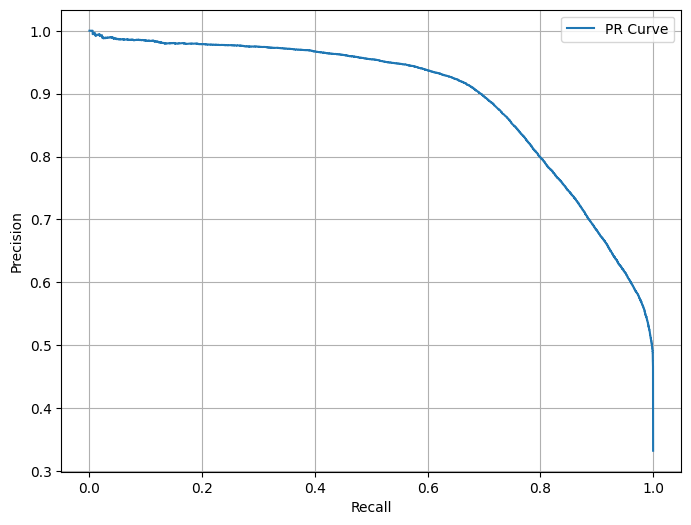

In [ ]:
auc_roc = roc_auc_score(y_val, y_pred)
auc_pr = average_precision_score(y_val, y_pred)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.35582703


In [ ]:
threshold = optimal_threshold
y_pred = (y_pred > threshold).astype(int)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91     64201
           1       0.83      0.77      0.80     31952

    accuracy                           0.87     96153
   macro avg       0.86      0.85      0.85     96153
weighted avg       0.87      0.87      0.87     96153



In [ ]:
print(confusion_matrix(y_val, y_pred))

[[59170  5031]
 [ 7285 24667]]


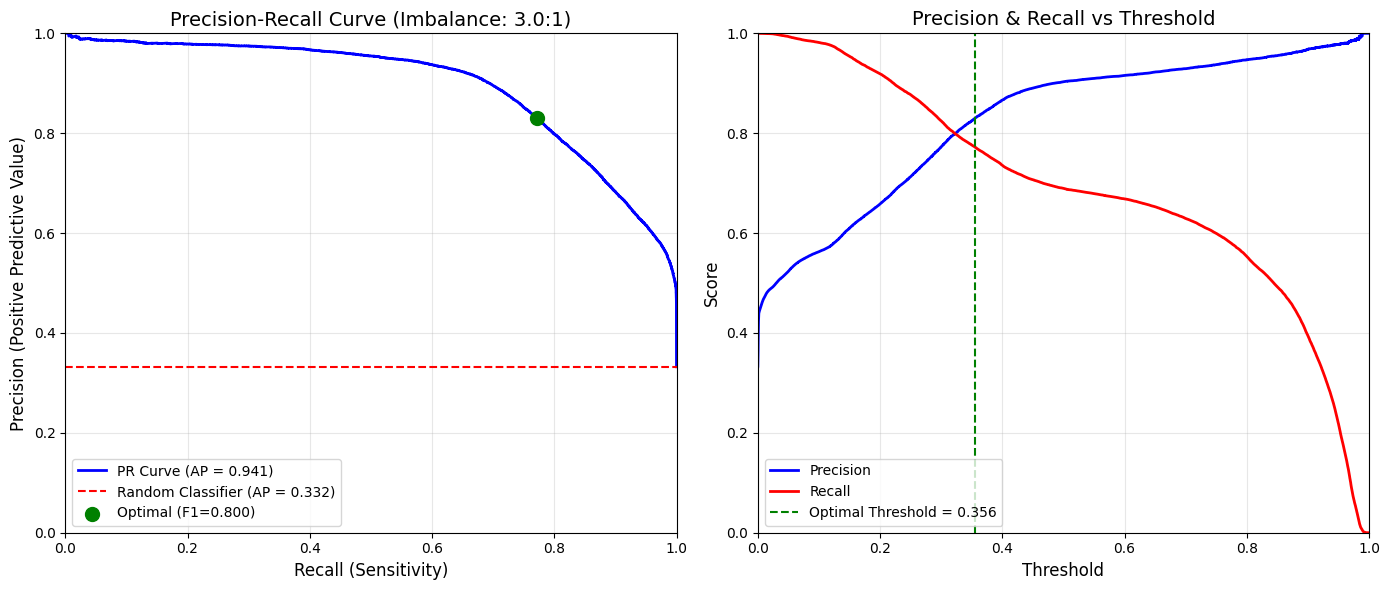

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
print(len(y_pred))
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_5_probs_idx = np.argsort(-customer_probs)[:5]
  top_5_probs_idx = top_5_probs_idx + start
  idx_list.extend(top_5_probs_idx)
y_val_top = y_val[idx_list]
y_pred_top = y_pred[idx_list]

96153


In [ ]:
print(len(y_val_top))
print(len(y_pred_top))

20030
20030


Test data performance:
AUC-ROC: 0.8220
AUC-PR: 0.9710


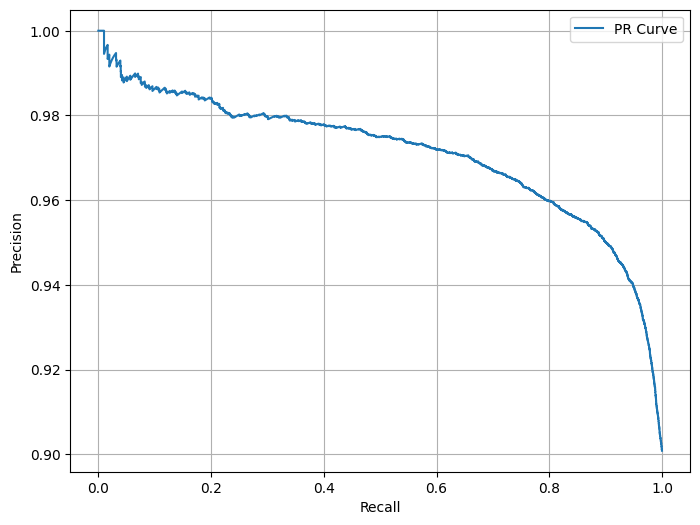

In [ ]:
auc_roc = roc_auc_score(y_val_top, y_pred_top)
auc_pr = average_precision_score(y_val_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_val_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.39627716


In [ ]:
threshold = optimal_threshold
y_pred = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top))

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
threshold = 0.35582703
y_pred_top = (y_pred_top > threshold).astype(int)
print(classification_report(y_val_top, y_pred_top))

              precision    recall  f1-score   support

           0       1.00      0.42      0.59   2770569
           1       0.01      0.99      0.03     23265

    accuracy                           0.42   2793834
   macro avg       0.51      0.70      0.31   2793834
weighted avg       0.99      0.42      0.59   2793834



In [ ]:
print(confusion_matrix(y_val_top, y_pred_top))

[[22298123    21548]
 [   20607    10394]]


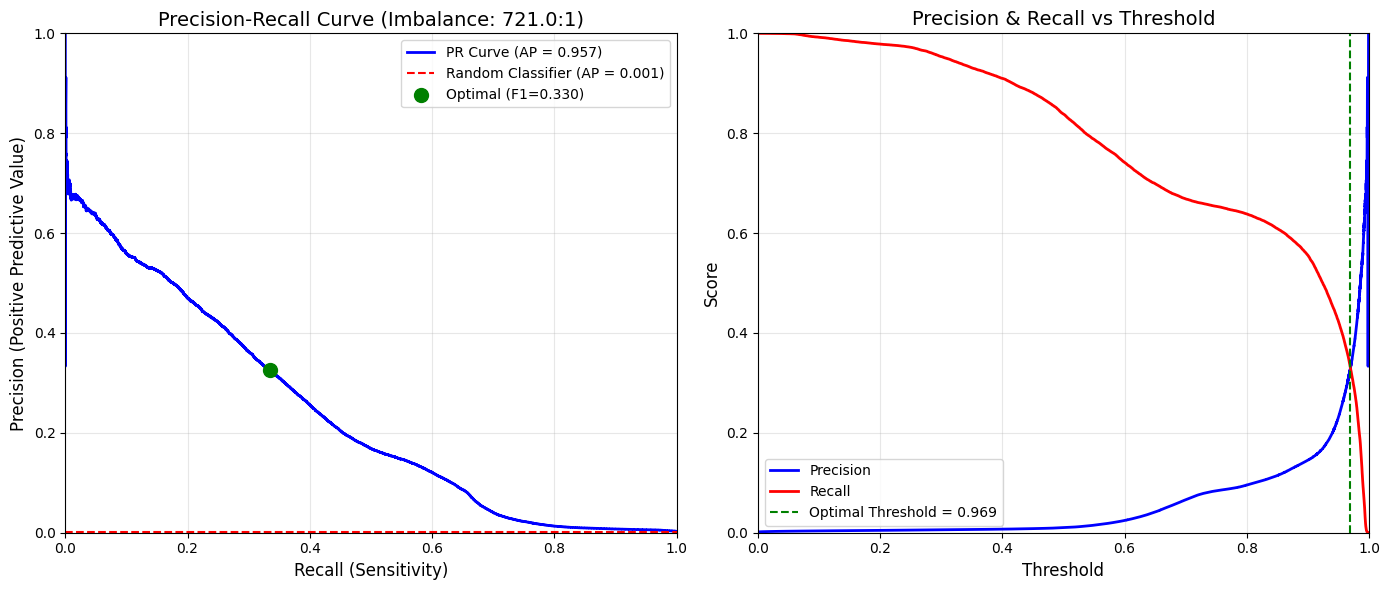

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_val_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()